# Initial figures

- Sensors: Vectors (ADVs) and the reef-flat Paros pressure sensors (P), from the QC'd files `data/processed/qc/{S}_QC.nc`.
- Spectral files are saved to 
- Figures are saved to `figs/initial/`.



In [9]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import spectrogram, welch
from granolas import sensor_spectra, multi_spectrogram, compute_H0, Hs_band, ztest

# paths
QC_DIR   = '../data/processed/qc'
META_DIR = '../data/metadata'
FIG_DIR  = '../figs/initial'

# constants
RHO = 1025.0     # seawater density [kg/m^3]
G   = 9.81       # gravity [m/s^2]
FS  = 2.0        # Vector and Paros sample rate [Hz]

# barbers point buoy data
buoy = pd.read_csv(f'{META_DIR}/cdip238_waves.csv', index_col='time', parse_dates=True)

# NOAA 1612340 tide data (Honolulu harbor)
tide = pd.read_csv(f'{META_DIR}/noaa_1612340_water_level.csv', index_col=0, parse_dates=True)['Water Level']

# sensors
ADV_SENSORS = ['VA10', 'VB5', 'VC10', 'VC5', 'VD10', 'VD5', 'VE10', 'VE7', 'VE4']
P_SENSORS   = ['PB1', 'PB2', 'PC1', 'PD1', 'PE1']      # Paros, pressure only, reef flat ~2-3 m
ALL_SENSORS = ADV_SENSORS + P_SENSORS
qc = {S: xr.open_dataset(f'{QC_DIR}/{S}_QC.nc') for S in ALL_SENSORS}
for S in ALL_SENSORS:
    t = qc[S].time.values
    depth = float(qc[S].depth_h.median())               # median hourly depth [m]
    print(f'{S:5s} transect {S[1]}  {depth:4.1f} m   {str(t[0])[:16]} -> {str(t[-1])[:16]}')



FAUSTO = ('2026-07-19', '2026-07-27')
LALA = ('2026-08-11', '2026-08-20')
LOWELL = ('2026-09-07', '2026-09-09')
FULL = ('2026-07-18', '2026-09-15')

VA10  transect A  10.4 m   2026-07-19T00:16 -> 2026-09-15T21:18
VB5   transect B   4.6 m   2026-07-19T23:13 -> 2026-09-15T20:44
VC10  transect C  11.0 m   2026-07-19T20:34 -> 2026-09-15T19:27
VC5   transect C   5.3 m   2026-07-19T01:41 -> 2026-09-15T20:16
VD10  transect D  10.9 m   2026-07-20T00:32 -> 2026-09-15T23:52
VD5   transect D   5.3 m   2026-07-18T22:29 -> 2026-09-15T22:10
VE10  transect E  10.7 m   2026-07-20T01:31 -> 2026-09-15T23:23
VE7   transect E   7.5 m   2026-07-18T19:56 -> 2026-09-15T22:59
VE4   transect E   4.2 m   2026-07-18T21:14 -> 2026-09-15T22:36
PB1   transect B   2.3 m   2026-07-28T18:23 -> 2026-09-16T22:38
PB2   transect B   2.7 m   2026-07-28T19:16 -> 2026-09-16T22:24
PC1   transect C   2.4 m   2026-07-28T20:25 -> 2026-09-16T20:43
PD1   transect D   3.0 m   2026-08-05T22:07 -> 2026-09-16T19:04
PE1   transect E   2.7 m   2026-08-05T21:00 -> 2026-09-16T19:42


VA10  transect A  10.4 m   2026-07-19T00:16 -> 2026-09-15T21:18
VB5   transect B   4.6 m   2026-07-19T23:13 -> 2026-09-15T20:44
VC10  transect C  11.0 m   2026-07-19T20:34 -> 2026-09-15T19:27
VC5   transect C   5.3 m   2026-07-19T01:41 -> 2026-09-15T20:16
VD10  transect D  10.9 m   2026-07-20T00:32 -> 2026-09-15T23:52
VD5   transect D   5.3 m   2026-07-18T22:29 -> 2026-09-15T22:10
VE10  transect E  10.7 m   2026-07-20T01:31 -> 2026-09-15T23:23
VE7   transect E   7.5 m   2026-07-18T19:56 -> 2026-09-15T22:59
VE4   transect E   4.2 m   2026-07-18T21:14 -> 2026-09-15T22:36
PB1   transect B   2.3 m   2026-07-28T18:23 -> 2026-09-16T22:38
PB2   transect B   2.7 m   2026-07-28T19:16 -> 2026-09-16T22:24
PC1   transect C   2.4 m   2026-07-28T20:25 -> 2026-09-16T20:43
PD1   transect D   3.0 m   2026-08-05T22:07 -> 2026-09-16T19:04
PE1   transect E   2.7 m   2026-08-05T21:00 -> 2026-09-16T19:42


## Plot style
- Color = transect: A/B IndianRed, C olive, D cobalt, E near-black.
- Line style = depth: 10 m solid, 7 m dash-dot, 4–5 m dashed, reef-flat P sensors dotted (PB2 dash-dot-dot, so it differs from PB1).
- Medium-large fonts for slides.

In [10]:
# claude's fancy plot data

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8,'axes.titlesize': 15,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 12, 'legend.frameon': False,
    'lines.linewidth': 1.2,
})

# color by transect 
T_COLOR = {'A': 'indianred', 'B': 'indianred', 'C': '#708238', 'D': '#0047AB', 'E': '0.15'}

# line style by depth
DEPTH_LS = {'10': '-', '7': '-.', '5': '--', '4': '--',
            '1': ':', '2': (0, (3, 1, 1, 1, 1, 1))}   # P sensors: the digit is the sensor number, not depth. PB2 gets its own style

BUOY_COLOR = '0.65'   # light grey 

# usage:  color=T_COLOR[S[1]], ls=DEPTH_LS[S[2:]]

Take spectra and bulk stats. Change inputs accordings **Warning**: takes 5 min to run all the spectra and bulk stats. If you want to run only a subset of sensors, change the `SENSORS` list below (e.g. `P_SENSORS`, ~10 s each).

- To skip this cell, run **Load saved spectra** below instead (seconds instead of ~5 min).
- `SPEC_START`, `SPEC_END` compute the spectra for a date range only (e.g. one event). Saved runs get the dates in the file name.


In [ ]:
# take spectra. make sure to detrend. Use scripts from granolas. 

# ============ INPUTS ============
SENSORS    = ALL_SENSORS    # e.g. ['VC5'] to test one sensor quickly
SPEC_START, SPEC_END = None, None   # e.g. '2026-09-05', '2026-09-12' for an event; None = whole record
NPERSEG    = 1024           # samples per FFT window: 1024 at 2 Hz = 512 s, df = 0.002 Hz
OVERLAP    = 0.5            # window overlap fraction
AVG        = '1h'           # average window spectra over this period before Hs, Tp, Dm
FMIN, FMAX = 0.04, 0.25     # sea-swell band for Hs, Tp, Dm [Hz]
F_CUT      = 0.5            # S_eta set to 0 above this [Hz]
USE_SEG_OK = True           # drop hours that failed QC (seg_ok = False)
# ================================


# Build an xarray dataset for each sensor's spectra
spec = {}
for S in SENSORS:
    ds  = qc[S].sel(time=slice(SPEC_START, SPEC_END))                   # only the requested dates
    if S[0] == 'V':
        df = ds[['p', 'u', 'v', 'w', 'u_east', 'v_north']].to_dataframe()   # 2 Hz record (~10 M rows)
    else:
        df = ds[['p']].to_dataframe()                                       # Paros: pressure only

    # ---- pressure and depth ----
    df['p_Pa']   = df.p * 1e4                          # dbar to Pa (what granolas expects)
    df['p_head'] = df.p * 1e4 / (RHO * G)              # hydrostatic head [m]
    df['h']      = df.p_head.rolling(NPERSEG, center=True, min_periods=1).mean()   # avg to smooth over waves

    # take the spectra
    if S[0] == 'V':
        # 1. surface elevation S_eta from pressure, cosh(kh) transfer
        sp = sensor_spectra(df, nperseg=NPERSEG, overlap_frac=OVERLAP,
                            pressure_col='p_Pa', depth_col='h', f_cutoff=F_CUT)

        # 2. pressure-head and velocity spectra, plus the p-velocity co-spectra (for Dm)
        xs = multi_spectrogram(df, columns=['p_head', 'u', 'v', 'w'],
                               pairs=[('p_head', 'u_east'), ('p_head', 'v_north')],
                               nperseg=NPERSEG, overlap_frac=OVERLAP)
        xs = xs.rename({'S_p_head': 'Spp', 'S_u': 'Suu', 'S_v': 'Svv', 'S_w': 'Sww',      # short names
                        'Co_p_head_u_east': 'Co_pE', 'Co_p_head_v_north': 'Co_pN'})
        xs = xs.drop_vars(['Quad_p_head_u_east', 'Quad_p_head_v_north'])                  # not needed here
        sp = sp.merge(xs)                                                                  # one Dataset per sensor
        del df, xs                                                                         # free memory before the next sensor
    else:
        # Paros: one raw file per hour with a 17 s gap between files. Take the spectra file by file,
        # so no FFT window spans a gap (12 windows per file). Same S_eta and Spp as above, no velocity.
        file_id = np.cumsum(np.diff(df.index.asi8, prepend=df.index.asi8[0]) > 1e9)   # +1 at every gap > 1 s
        pieces = []
        for _, one_file in df.groupby(file_id):
            if len(one_file) < NPERSEG:                    # partial file, too short for one window
                continue
            file_hour = one_file.index[0].floor('h')       # P seg_ok is labelled by the file's start hour, not clock hour
            if USE_SEG_OK and not ds.seg_ok.sel(hour=file_hour):
                continue                                   # drop files that failed QC
            sp_file = sensor_spectra(one_file, nperseg=NPERSEG, overlap_frac=OVERLAP,
                                     pressure_col='p_Pa', depth_col='h', f_cutoff=F_CUT)
            xs_file = multi_spectrogram(one_file, columns=['p_head'], nperseg=NPERSEG, overlap_frac=OVERLAP)
            pieces.append(sp_file.merge(xs_file.rename({'S_p_head': 'Spp'})))
        sp = xr.concat(pieces, dim='time')
        del df, pieces

    # the clock-drift correction makes dt slightly off 0.5 s, differently for each sensor, so the frequencies
    # differ in the 6th digit. Put every sensor on the nominal grid so they line up when combined.
    sp = sp.assign_coords(frequency=np.fft.rfftfreq(NPERSEG, 1 / FS))

    # ---- drop windows in hours that failed QC (ADVs; P files were dropped in the loop above) ----
    if USE_SEG_OK and S[0] == 'V':
        win_hour = pd.DatetimeIndex(sp.time.values).floor('h')                 # clock hour of each window center
        ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values      # seg_ok for that hour
        sp = sp.where(xr.DataArray(ok.astype(bool), dims='time'))

    # ---- average window spectra over AVG ----
    sp = sp.resample(time=AVG).mean()

    # ---- Hs, Tp (granolas compute_H0, over FMIN-FMAX) ----
    good = sp.dropna('time', subset=['h_mean'])                    # compute_H0 can't take all-NaN times
    bulk = compute_H0(good, fmin=FMIN, fmax=FMAX)                  # DataFrame: Hs, Tp, H0, h
    bulk = bulk.reindex(sp.time.values)                            # back onto the full time grid
    sp['Hs'] = ('time', bulk.Hs.values)
    sp['Tp'] = ('time', bulk.Tp.values)

    # ---- Dm: direction waves come FROM [deg true] ----
    if S[0] == 'V':
        band   = sp.sel(frequency=slice(FMIN, FMAX))
        toward = np.degrees(np.arctan2(band.Co_pE.sum('frequency'), band.Co_pN.sum('frequency')))
        sp['Dm'] = (toward + 180) % 360
        sp['Dm'] = sp.Dm.where(sp.Hs.notnull())                    # NaN where the hour was dropped
    else:
        sp['Dm'] = sp.Hs * np.nan                                  # Paros: no velocity, no Dm

    # ---- labels ----
    sp['Hs'].attrs = {'units': 'm',        'long_name': f'Hs = 4 sqrt(m0), {FMIN}-{FMAX} Hz'}
    sp['Tp'].attrs = {'units': 's',        'long_name': f'peak period, {FMIN}-{FMAX} Hz'}
    sp['Dm'].attrs = {'units': 'deg true', 'long_name': f'mean wave direction, coming FROM, {FMIN}-{FMAX} Hz'}
    sp.attrs.update({'sensor': S, 'transect': S[1], 'depth_m': round(float(ds.depth_h.median()), 1),
                     'nperseg': NPERSEG, 'overlap': OVERLAP, 'avg': AVG, 'use_seg_ok': int(USE_SEG_OK),
                     'fmin': FMIN, 'fmax': FMAX, 'spec_start': str(SPEC_START), 'spec_end': str(SPEC_END)})
    spec[S] = sp

    # check: median Hs here / Hs_SS stored in the QC file (same band, hourly) -> should be ~1
    # (P sensors read ~1.1: their stored Hs_SS has no depth correction)
    ratio = (sp.Hs.to_series() / ds.Hs_SS.to_series()).median()
    print(f'{S:5s} {int(sp.Hs.notnull().sum()):5d} x {AVG}   median Hs {float(sp.Hs.median()):.2f} m   '
          f'Tp {float(sp.Tp.median()):.1f} s   Hs/Hs_SS {ratio:.3f}')

# file-name tag for saving: '' for the whole record, '_start_end' for a date run (so it doesn't overwrite the full files)
SPEC_TAG = '' if SPEC_START is None else f'_{SPEC_START}_{SPEC_END}'


VA10   1347 x 1h   median Hs 1.20 m   Tp 14.6 s   Hs/Hs_SS 0.989
VB5    1388 x 1h   median Hs 1.17 m   Tp 14.6 s   Hs/Hs_SS 0.994
VC10   1390 x 1h   median Hs 1.12 m   Tp 15.1 s   Hs/Hs_SS 0.988
VC5    1409 x 1h   median Hs 1.02 m   Tp 15.1 s   Hs/Hs_SS 0.989
VD10   1365 x 1h   median Hs 0.92 m   Tp 14.2 s   Hs/Hs_SS 0.984
VD5    1343 x 1h   median Hs 0.96 m   Tp 14.2 s   Hs/Hs_SS 0.990
VE10   1371 x 1h   median Hs 0.91 m   Tp 14.2 s   Hs/Hs_SS 0.985
VE7    1400 x 1h   median Hs 0.87 m   Tp 14.2 s   Hs/Hs_SS 0.988
VE4    1413 x 1h   median Hs 0.88 m   Tp 14.6 s   Hs/Hs_SS 0.991


In [5]:
# save the spectra as netcdf (whole record -> {S}_spec.nc, a date run -> {S}_spec_{start}_{end}.nc)
for S in spec:
    spec[S].to_netcdf(f'{QC_DIR}/{S}_spec{SPEC_TAG}.nc')


#### Load saved spectra
Run this **instead of** the spectra cell above. It reads the `{S}_spec.nc` files written by the save cell. To load a date run, set `LOAD_TAG` to its dates, e.g. `'_2026-09-05_2026-09-12'`.

In [11]:
# load saved spectra instead of rerunning the spectra cell

# ============ INPUTS ============
SENSORS  = ALL_SENSORS
LOAD_TAG = ''      # '' = whole record ({S}_spec.nc), or e.g. '_2026-09-05_2026-09-12' for a date run
# ================================

spec = {}
for S in SENSORS:
    # load_dataset reads the file into memory and closes it, so the save cell can overwrite it later
    spec[S] = xr.load_dataset(f'{QC_DIR}/{S}_spec{LOAD_TAG}.nc')
    # nominal frequency grid, so sensors line up (files saved before 2026-10-07 differ in the 6th digit)
    spec[S] = spec[S].assign_coords(frequency=np.fft.rfftfreq(spec[S].attrs['nperseg'], 1 / FS))
    t = spec[S].time.values
    print(f'{S:5s} {str(t[0])[:16]} -> {str(t[-1])[:16]}   {len(t)} x {spec[S].attrs["avg"]}')

# settings the figure cells use in their titles (normally set by the spectra cell)
AVG  = spec[S].attrs['avg']
FMIN = spec[S].attrs.get('fmin', 0.04)     # files saved before 2026-10-07 don't store the band; they used 0.04-0.25 Hz
FMAX = spec[S].attrs.get('fmax', 0.25)
SPEC_TAG = LOAD_TAG


VA10  2026-07-19T00:00 -> 2026-09-15T21:00   1414 x 1h
VB5   2026-07-19T23:00 -> 2026-09-15T20:00   1390 x 1h
VC10  2026-07-19T20:00 -> 2026-09-15T19:00   1392 x 1h
VC5   2026-07-19T01:00 -> 2026-09-15T20:00   1412 x 1h
VD10  2026-07-20T00:00 -> 2026-09-15T23:00   1392 x 1h
VD5   2026-07-18T22:00 -> 2026-09-15T22:00   1417 x 1h
VE10  2026-07-20T01:00 -> 2026-09-15T23:00   1391 x 1h
VE7   2026-07-18T20:00 -> 2026-09-15T22:00   1419 x 1h
VE4   2026-07-18T21:00 -> 2026-09-15T22:00   1418 x 1h
PB1   2026-07-28T19:00 -> 2026-09-16T21:00   1203 x 1h
PB2   2026-07-28T20:00 -> 2026-09-16T21:00   1202 x 1h
PC1   2026-07-28T21:00 -> 2026-09-16T19:00   1199 x 1h
PD1   2026-08-05T23:00 -> 2026-09-16T18:00   1004 x 1h
PE1   2026-08-05T21:00 -> 2026-09-16T18:00   1006 x 1h


## Bulk stats figs

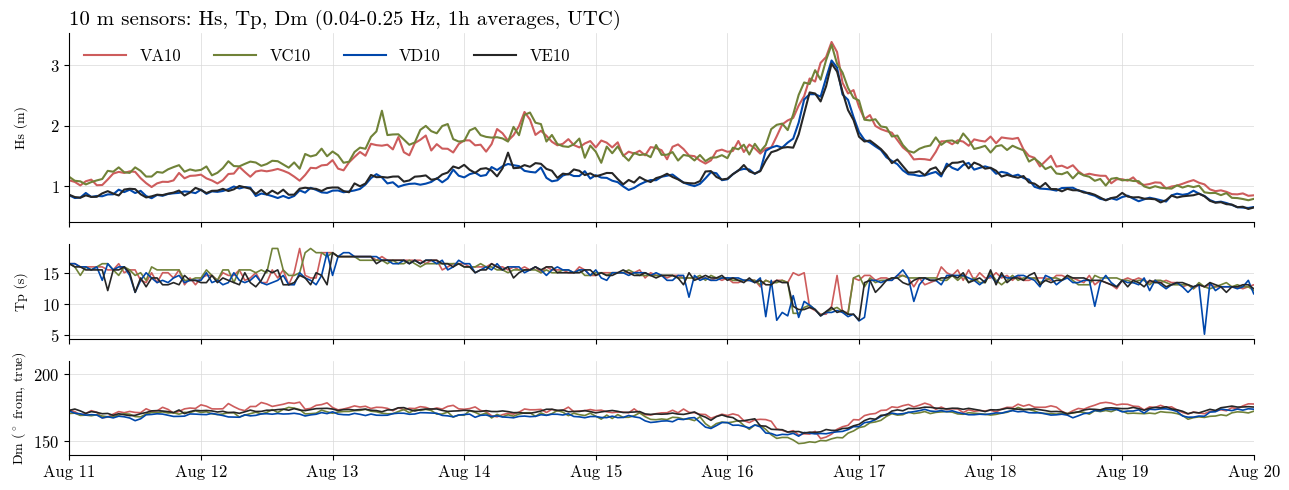

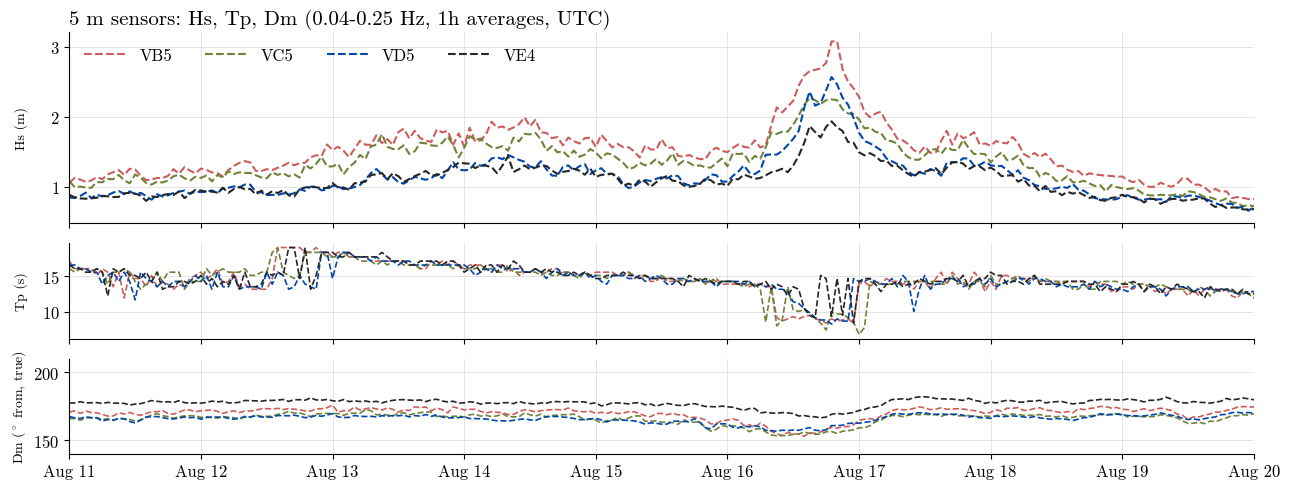

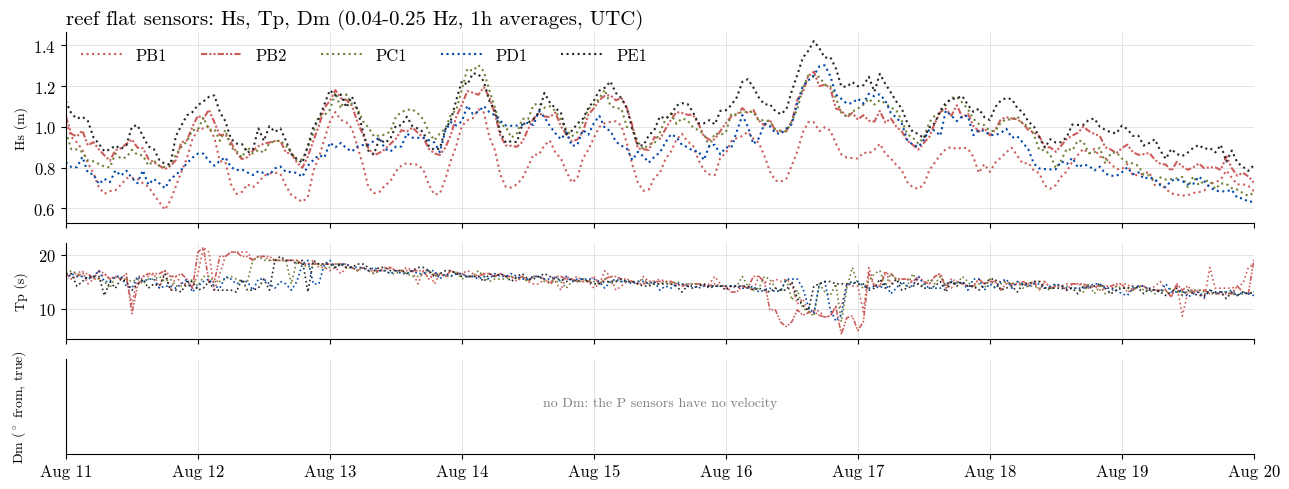

In [16]:
# For both 10m and 5m sensors, make a 3 panel figure with Hs, Tp, and Dm. One figure for 10m, another for 5m. Plot lines for each sensor. For transect E, You may use VE4. Label title clearly

# ============ INPUTS ============
SENSORS_10M = ['VA10', 'VC10', 'VD10', 'VE10']
SENSORS_5M  = ['VB5', 'VC5', 'VD5', 'VE4']
SENSORS_P   = P_SENSORS     # reef flat, ~2-3 m (no Dm: pressure only)
T_START, T_END = LALA  # e.g. '2026-09-05', '2026-09-12' to zoom on an event
HS_YLIM   = None            # e.g. (0, 3); None = automatic
TP_YLIM   = None            # e.g. (5, 25)
DM_YLIM   = (140,210)            # e.g. (140, 220)
HEIGHT_RATIOS = (2, 1, 1)   # panel heights Hs : Tp : Dm
SMOOTH    = None            # centered running mean on Hs, Tp, Dm (and buoy), e.g. '3h', '6h'; None = raw hourly
SHOW_BUOY = False
SAVE      = False
# ================================

for group, sensors in [('10 m', SENSORS_10M), ('5 m', SENSORS_5M), ('reef flat', SENSORS_P)]:
    fig, axs = plt.subplots(3, 1, figsize=(13, 5), sharex=True,
                            gridspec_kw={'height_ratios': HEIGHT_RATIOS})   # Hs panel taller

    if SHOW_BUOY:
        b = buoy[T_START:T_END]
        if SMOOTH:
            b = b[['Hs', 'Tp', 'Dp']].rolling(SMOOTH, center=True).mean()   # same running mean as the sensors
        axs[0].plot(b.index, b.Hs, color=BUOY_COLOR, lw=1, label='buoy (CDIP 238)')
        axs[1].plot(b.index, b.Tp, '.', ms=3, color=BUOY_COLOR)
        axs[2].plot(b.index, b.Dp, '.', ms=3, color=BUOY_COLOR)

    for S in sensors:
        if S not in spec:
            print(f'{S} skipped: not in spec (rerun the spectra cell with it in SENSORS)')
            continue
        d = spec[S][['Hs', 'Tp', 'Dm']].sel(time=slice(T_START, T_END)).to_dataframe()   # hourly, as a DataFrame
        if SMOOTH:
            d = d.rolling(SMOOTH, center=True).mean()        # plain mean of Dm is fine here: no values near 0/360
        color, ls = T_COLOR[S[1]], DEPTH_LS[S[2:]]
        axs[0].plot(d.index, d.Hs, color=color, ls=ls, label=S, linewidth=1.5)   # Hs lines a bit thicker
        axs[1].plot(d.index, d.Tp, color=color, ls=ls)          # steppy: Tp jumps between frequency bins
        axs[2].plot(d.index, d.Dm, color=color, ls=ls)
    axs[0].set_ylabel('Hs (m)')
    axs[1].set_ylabel('Tp (s)')
    axs[2].set_ylabel(r'Dm ($^\circ$ from, true)')
    axs[0].set_ylim(HS_YLIM)                                # None leaves the limits automatic
    axs[1].set_ylim(TP_YLIM)
    axs[2].set_ylim(DM_YLIM)
    axs[0].legend(ncol=5, loc='upper left', handlelength=2.5)
    if group == 'reef flat':
        axs[2].text(0.5, 0.5, 'no Dm: the P sensors have no velocity', transform=axs[2].transAxes, ha='center', color='0.5')
        axs[2].set_yticks([])
    smooth_txt = f', {SMOOTH} running mean' if SMOOTH else ''
    axs[0].set_title(f'{group} sensors: Hs, Tp, Dm ({FMIN}-{FMAX} Hz, {AVG} averages{smooth_txt}, UTC)', loc='left')

    axs[-1].set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for ax in axs:
        ax.grid(True, lw=0.5, color='0.85')
    fig.align_ylabels(axs)
    fig.tight_layout()
    if SAVE:
        smooth_tag = f'_smooth{SMOOTH}' if SMOOTH else ''           # so a smoothed figure doesn't overwrite the raw one
        fig.savefig(f'{FIG_DIR}/bulk_{group.replace(" ", "")}_{T_START}_{T_END}{smooth_tag}.png', dpi=200)
    plt.show()

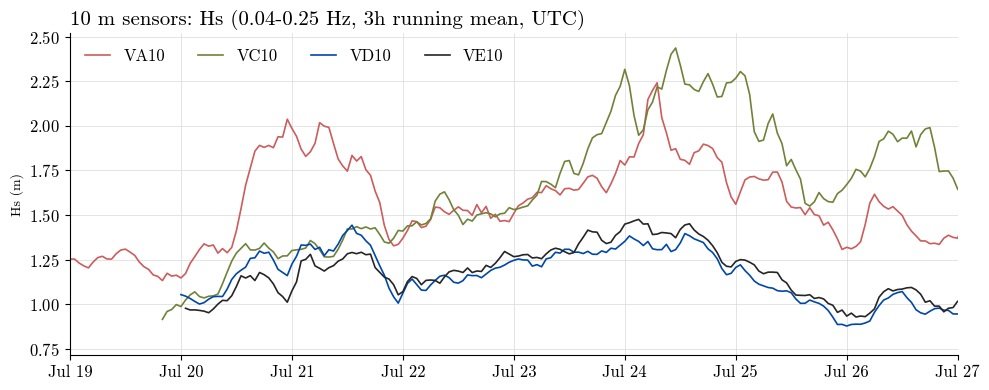

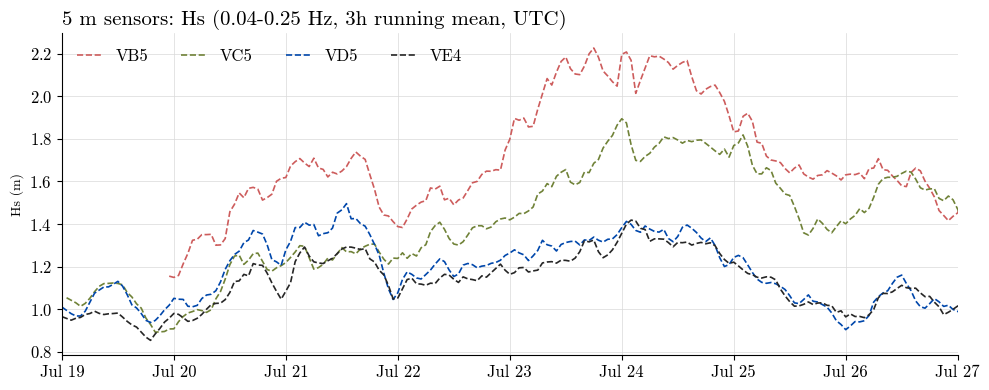

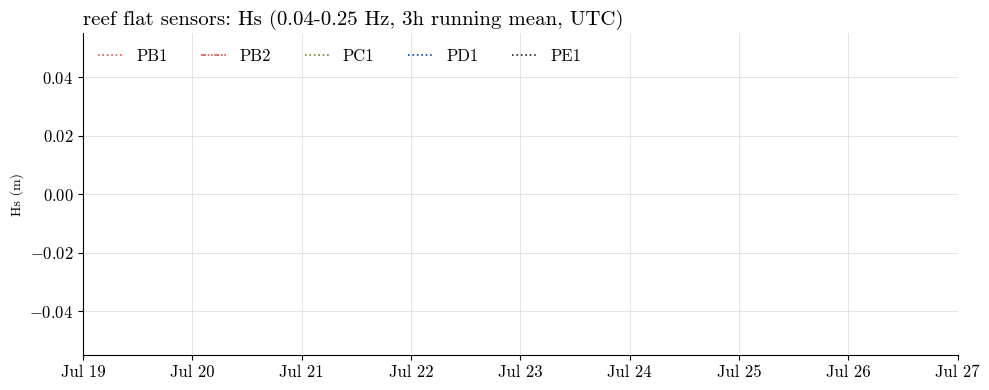

In [28]:
# Hs plot (uses SENSORS_10M, SENSORS_5M, SENSORS_P, T_START, T_END, HS_YLIM, SHOW_BUOY and SAVE from the cell above)

# ============ INPUTS ============
SMOOTH = '3h'     # centered running mean, e.g. '3h', '6h'; None = no smoothing
# ================================

for group, sensors in [('10 m', SENSORS_10M), ('5 m', SENSORS_5M), ('reef flat', SENSORS_P)]:
    fig, axs = plt.subplots(1, 1, figsize=(10, 4))

    if SHOW_BUOY:
        b = buoy[T_START:T_END]
        hs_buoy = b.Hs
        if SMOOTH:
            hs_buoy = hs_buoy.rolling(SMOOTH, center=True).mean()     # running mean over SMOOTH
        axs.plot(hs_buoy.index, hs_buoy, color=BUOY_COLOR, lw=1, label='buoy (CDIP 238)')


    for S in sensors:
        hs = spec[S].Hs.sel(time=slice(T_START, T_END)).to_series()   # hourly Hs as a pandas Series
        if SMOOTH:
            hs = hs.rolling(SMOOTH, center=True).mean()                # running mean over SMOOTH (skips gaps)
        color, ls = T_COLOR[S[1]], DEPTH_LS[S[2:]]
        axs.plot(hs.index, hs, color=color, ls=ls, label=S)

    axs.set_ylabel('Hs (m)')
    axs.set_ylim(HS_YLIM)                                # None leaves the limits automatic
    axs.legend(ncol=5, loc='upper left', handlelength=1.5)
    smooth_txt = f', {SMOOTH} running mean' if SMOOTH else ''
    axs.set_title(f'{group} sensors: Hs ({FMIN}-{FMAX} Hz{smooth_txt}, UTC)', loc='left')

    axs.set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axs.grid(True, lw=0.5, color='0.85')
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/Hs_{group.replace(" ", "")}_{T_START}_{T_END}.png', dpi=200)   # Hs_ so it doesn't overwrite the 3-panel figure
    plt.show()


#### Bulk stats by transect
Same panels as above, one figure per transect. Color and line style both show depth: 10 m cobalt solid, 7 m olive dash-dot, 4–5 m IndianRed dashed, reef-flat P sensors near-black dotted (no Dm). Transect A has one sensor.

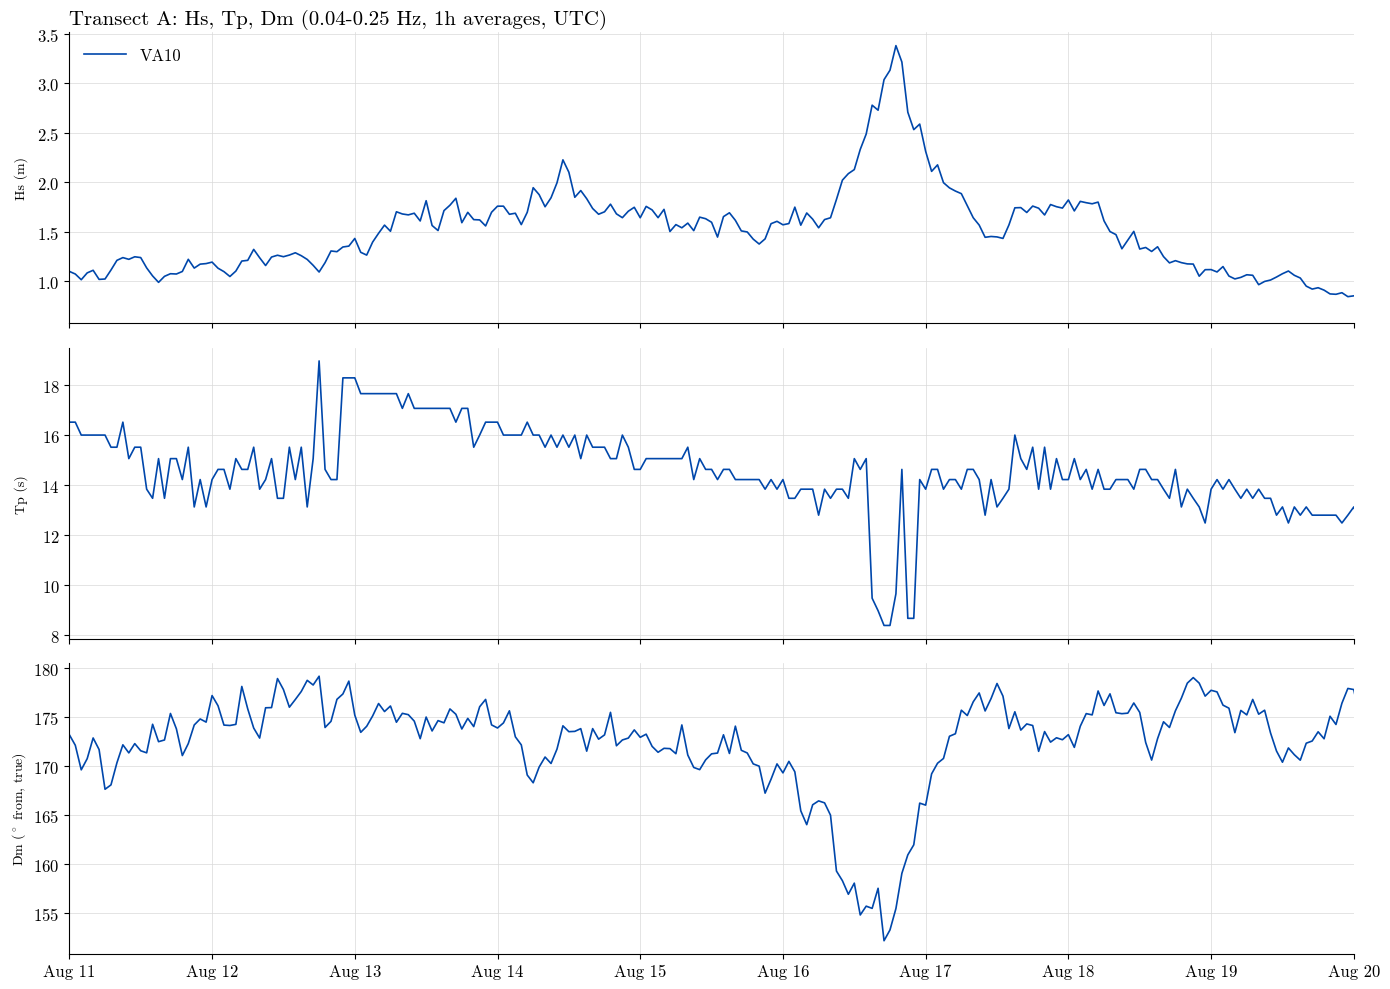

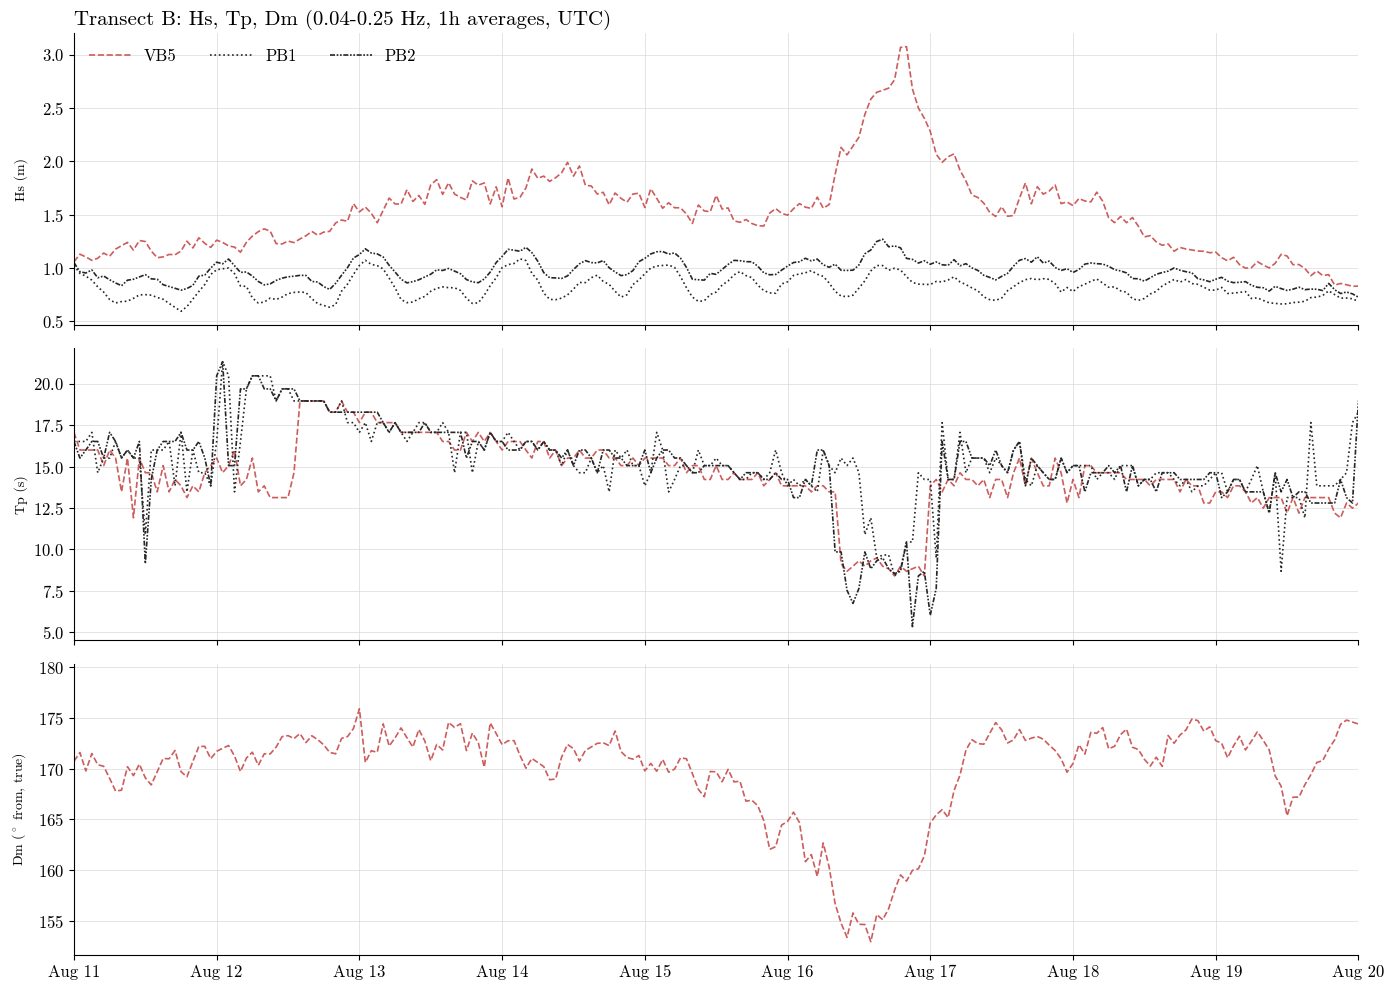

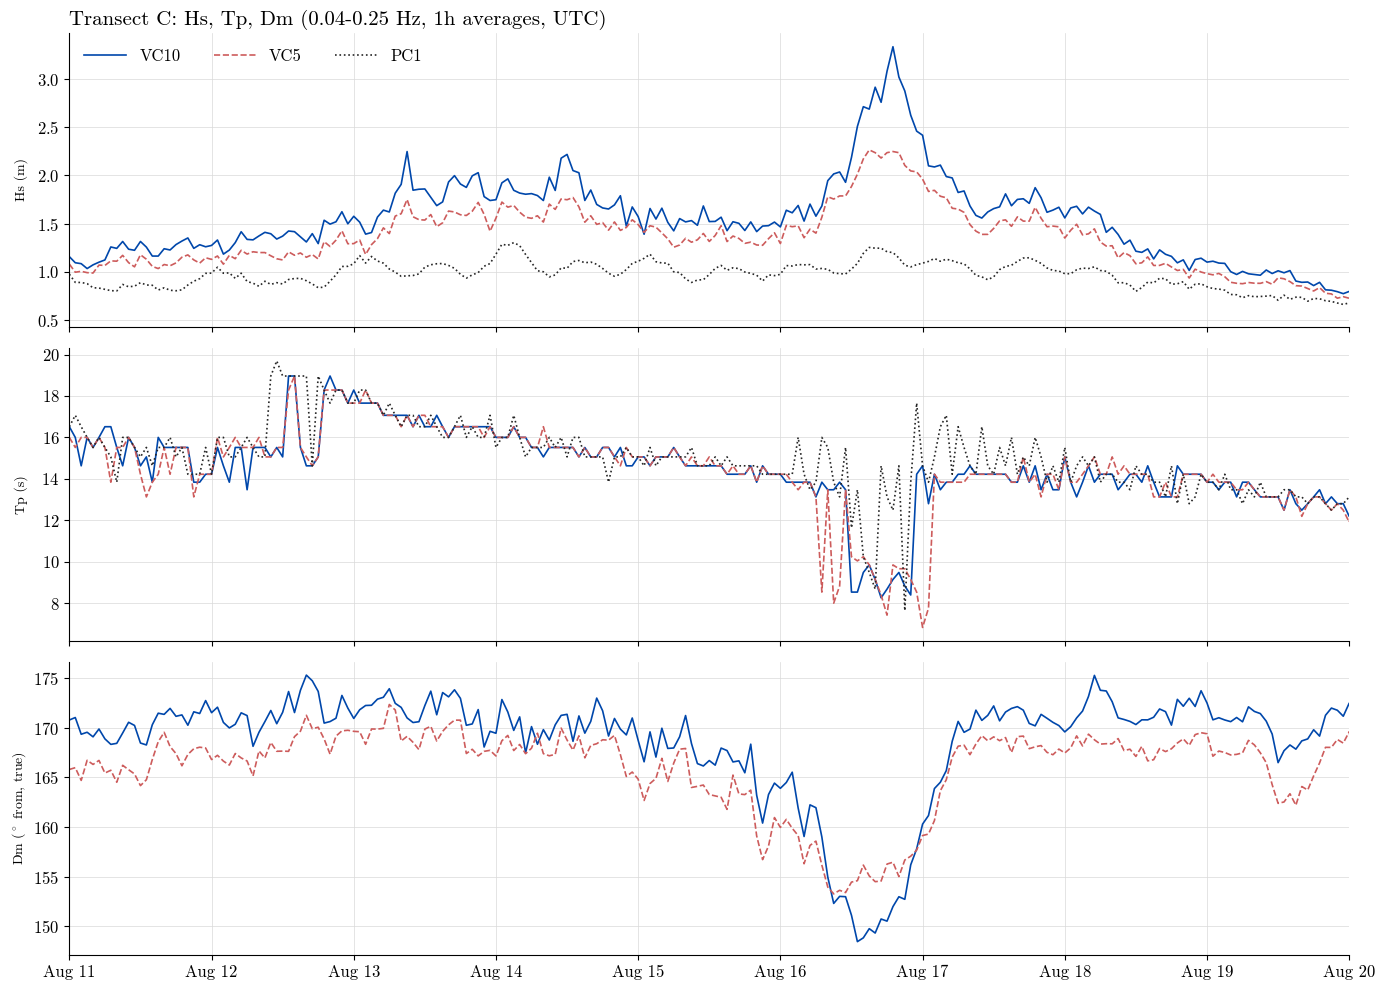

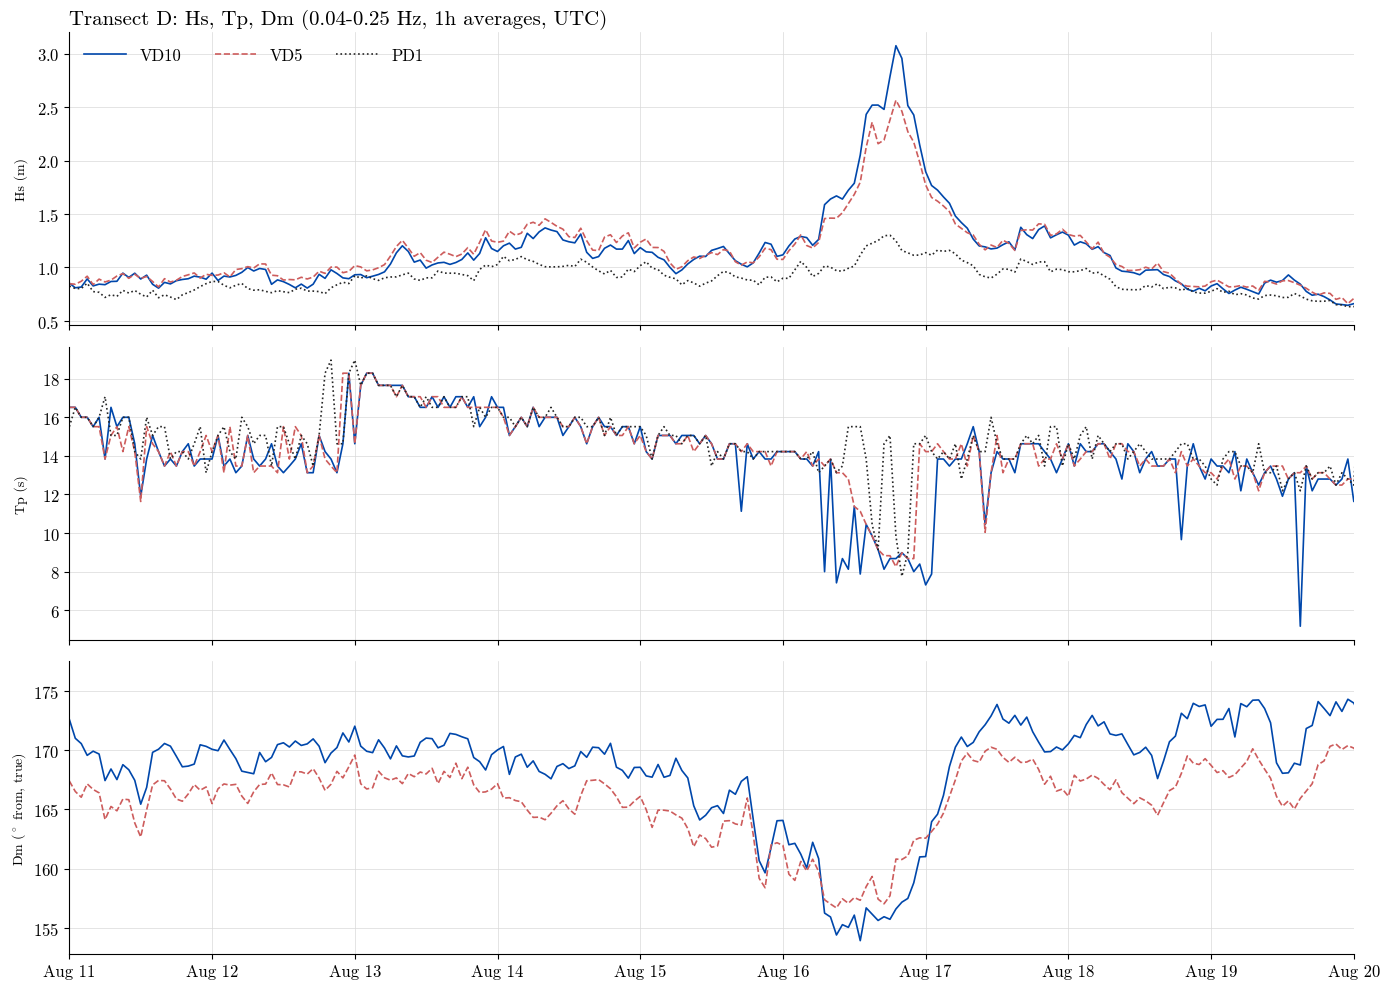

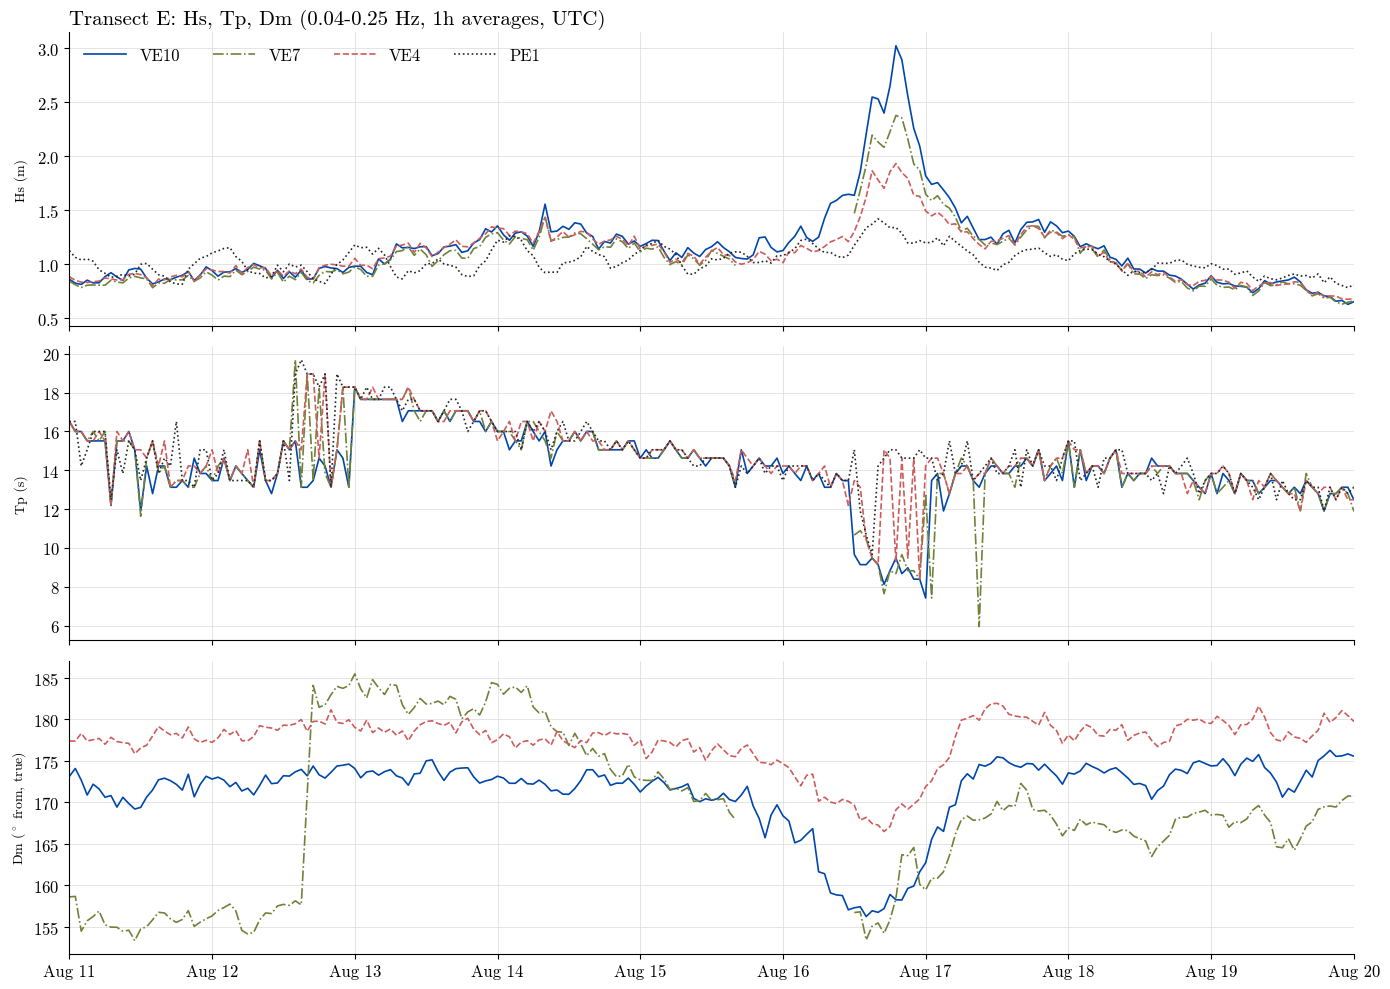

In [17]:
# Hs, Tp, Dm by transect: one 3-panel figure per transect, one line per sensor on that transect

# ============ INPUTS ============
TRANSECTS = ['A', 'B', 'C', 'D', 'E']    # e.g. ['C', 'E']
T_START, T_END = LALA
HS_YLIM   = None            # e.g. (0, 3); None = automatic
TP_YLIM   = None            # e.g. (5, 25)
DM_YLIM   = None            # e.g. (140, 220)
SHOW_BUOY = False
SAVE      = False
# ================================

# within one transect every sensor has the same transect color, so color by depth here instead
DEPTH_COLOR = {'10': '#0047AB', '7': '#708238', '5': 'indianred', '4': 'indianred',
               '1': '0.15', '2': '0.15'}    # P sensors (reef flat): near-black, PB1 vs PB2 by line style

for T in TRANSECTS:
    sensors = [S for S in spec if S[1] == T]           # sensors on this transect, deep -> shallow
    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    if SHOW_BUOY:
        b = buoy[T_START:T_END]
        axs[0].plot(b.index, b.Hs, color=BUOY_COLOR, lw=1, label='buoy (CDIP 238)')
        axs[1].plot(b.index, b.Tp, '.', ms=3, color=BUOY_COLOR)
        axs[2].plot(b.index, b.Dp, '.', ms=3, color=BUOY_COLOR)

    for S in sensors:
        d = spec[S].sel(time=slice(T_START, T_END))
        color, ls = DEPTH_COLOR[S[2:]], DEPTH_LS[S[2:]]
        axs[0].plot(d.time, d.Hs, color=color, ls=ls, label=S)
        axs[1].plot(d.time, d.Tp, color=color, ls=ls)
        axs[2].plot(d.time, d.Dm, color=color, ls=ls)

    axs[0].set_ylabel('Hs (m)')
    axs[1].set_ylabel('Tp (s)')
    axs[2].set_ylabel(r'Dm ($^\circ$ from, true)')
    axs[0].set_ylim(HS_YLIM)                                # None leaves the limits automatic
    axs[1].set_ylim(TP_YLIM)
    axs[2].set_ylim(DM_YLIM)
    axs[0].legend(ncol=4, loc='upper left', handlelength=2.5)
    axs[0].set_title(f'Transect {T}: Hs, Tp, Dm ({FMIN}-{FMAX} Hz, {AVG} averages, UTC)', loc='left')

    axs[-1].set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for ax in axs:
        ax.grid(True, lw=0.5, color='0.85')
    fig.align_ylabels(axs)
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/bulk_transect{T}_{T_START}_{T_END}.png', dpi=200)
    plt.show()


#### Hs by frequency band: Hs_tot, Hs_ss, Hs_ig


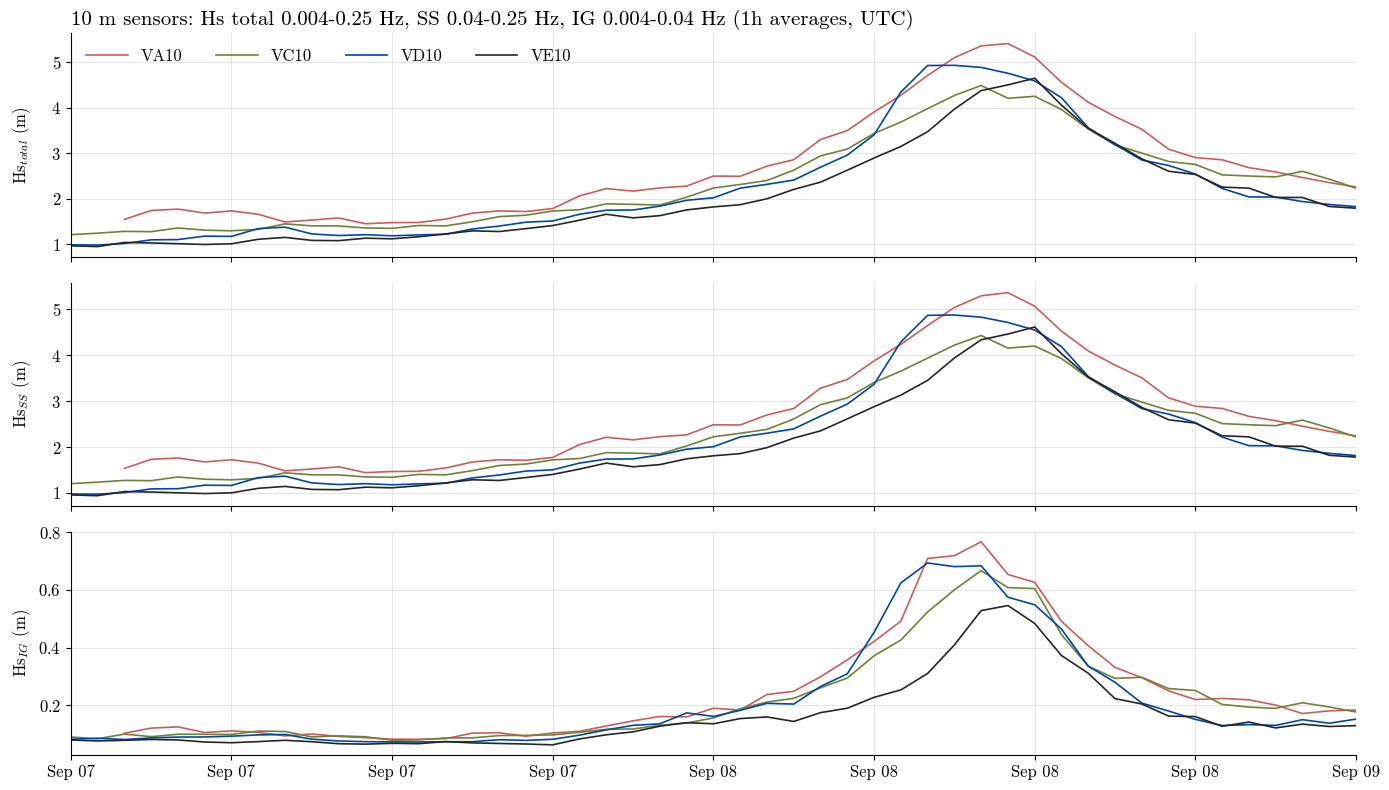

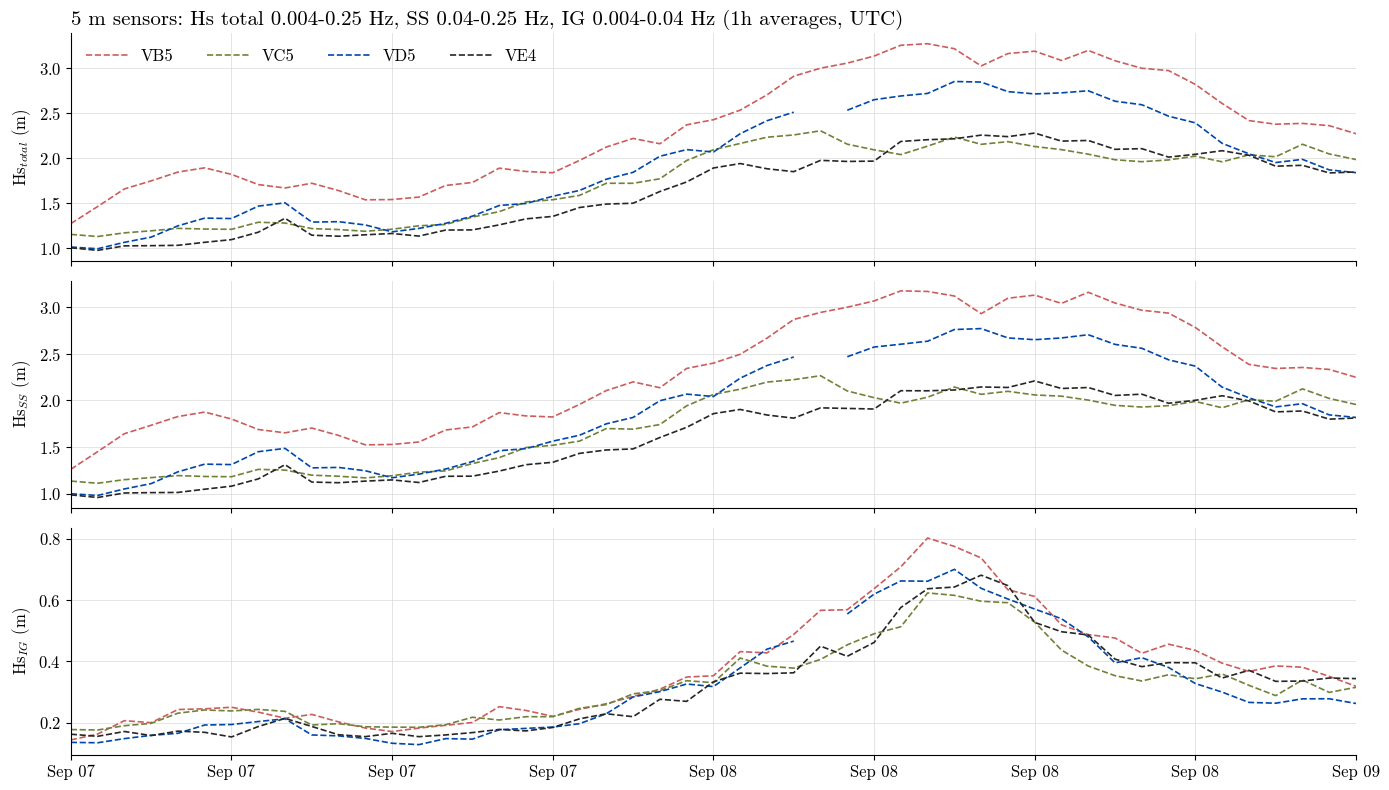

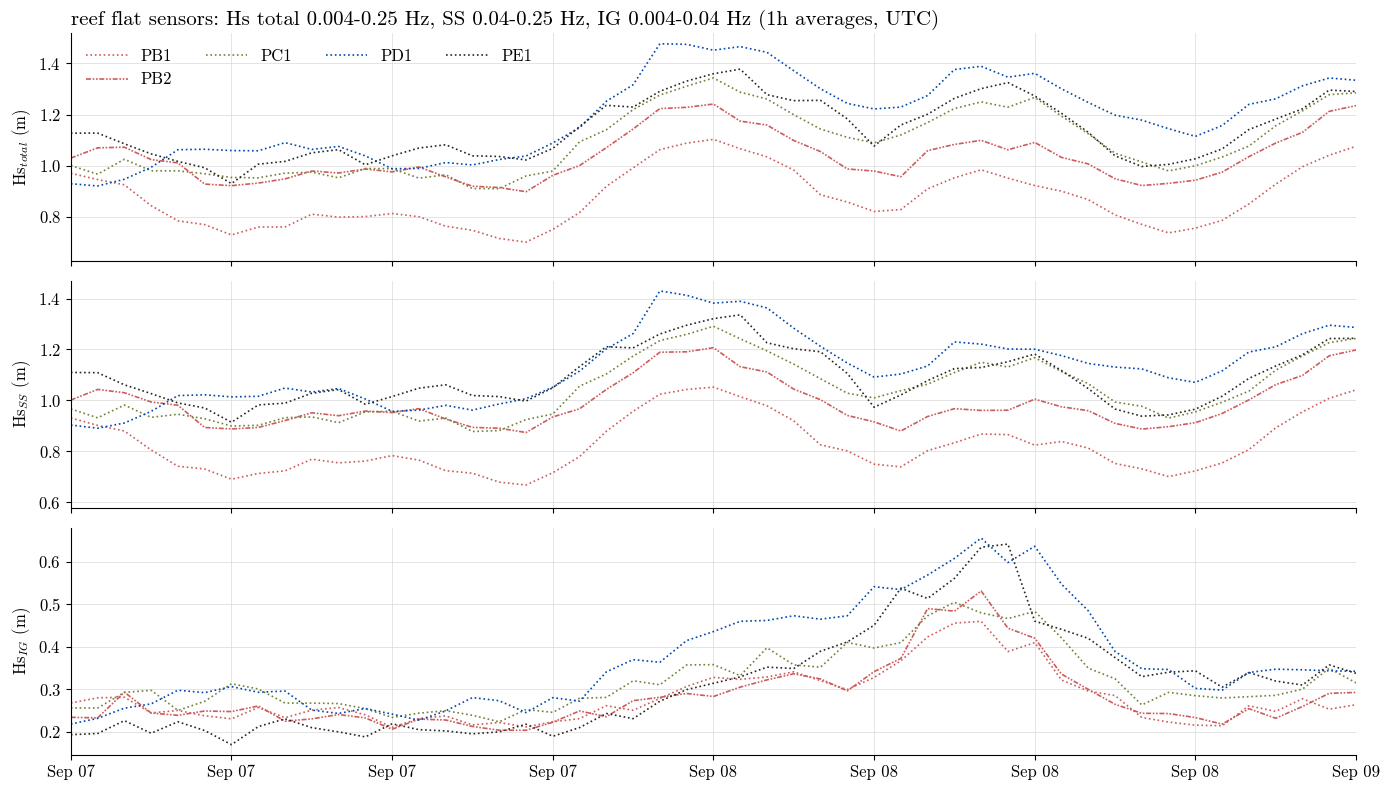

In [32]:
# Hs in three bands: total, sea-swell (SS) and infragravity (IG). One 3-panel figure for 10 m, one for 5 m

# ============ INPUTS ============
SENSORS_10M = ['VA10', 'VC10', 'VD10', 'VE10']
SENSORS_5M  = ['VB5', 'VC5', 'VD5', 'VE4']
SENSORS_P   = P_SENSORS     # reef flat, ~2-3 m
T_START, T_END = LOWELL
IG_BAND    = (0.004, 0.04)        # infragravity [Hz]
SS_BAND    = (0.04, 0.25)         # sea-swell [Hz]
TOTAL_BAND = (0.004, 0.25)        # total = IG + SS [Hz]
TOTAL_YLIM, SS_YLIM, IG_YLIM = None, None, None   # e.g. (0, 3); None = automatic
SAVE = True
# ================================

# Hs = 4 sqrt(m0), m0 = integral of S_eta over the band (granolas Hs_band)
for group, sensors in [('10 m', SENSORS_10M), ('5 m', SENSORS_5M), ('reef flat', SENSORS_P)]:
    fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for S in sensors:
        if S not in spec:
            print(f'{S} skipped: not in spec (run the spectra or load cell with it in SENSORS)')
            continue
        d = spec[S].sel(time=slice(T_START, T_END))
        hs_total = Hs_band(d, *TOTAL_BAND)
        hs_ss    = Hs_band(d, *SS_BAND)
        hs_ig    = Hs_band(d, *IG_BAND)
        color, ls = T_COLOR[S[1]], DEPTH_LS[S[2:]]
        axs[0].plot(d.time, hs_total, color=color, ls=ls, label=S)
        axs[1].plot(d.time, hs_ss,    color=color, ls=ls)
        axs[2].plot(d.time, hs_ig,    color=color, ls=ls)

    axs[0].set_ylabel(r'Hs$_{total}$ (m)', fontsize=12)
    axs[1].set_ylabel(r'Hs$_{SS}$ (m)', fontsize=12)
    axs[2].set_ylabel(r'Hs$_{IG}$ (m)', fontsize=12 )
    axs[0].set_ylim(TOTAL_YLIM)                     # None leaves the limits automatic
    axs[1].set_ylim(SS_YLIM)
    axs[2].set_ylim(IG_YLIM)
    axs[0].legend(ncol=4, loc='upper left', handlelength=2.5)
    axs[0].set_title(f'{group} sensors: Hs total {TOTAL_BAND[0]}-{TOTAL_BAND[1]} Hz, '
                     f'SS {SS_BAND[0]}-{SS_BAND[1]} Hz, IG {IG_BAND[0]}-{IG_BAND[1]} Hz ({AVG} averages, UTC)', loc='left')

    axs[-1].set_xlim(pd.Timestamp(T_START), pd.Timestamp(T_END))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    for ax in axs:
        ax.grid(True, lw=0.5, color='0.85')
    fig.align_ylabels(axs)
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/Hs_bands_{group.replace(" ", "")}_{T_START}_{T_END}.png', dpi=200)
    plt.show()


#### Hs_SS vs Hs_IG
One panel per sensor, each point is one hour, colored by water level $h$ (hourly mean depth from the pressure, `h_mean`).
- `H_TIDE = True`: $h$ minus each sensor's own record mean, i.e. the tide and setup. This puts all sensors on one color scale.
- `H_TIDE = False`: total depth $h$. The 5 m and 10 m sensors then sit at opposite ends of the scale.

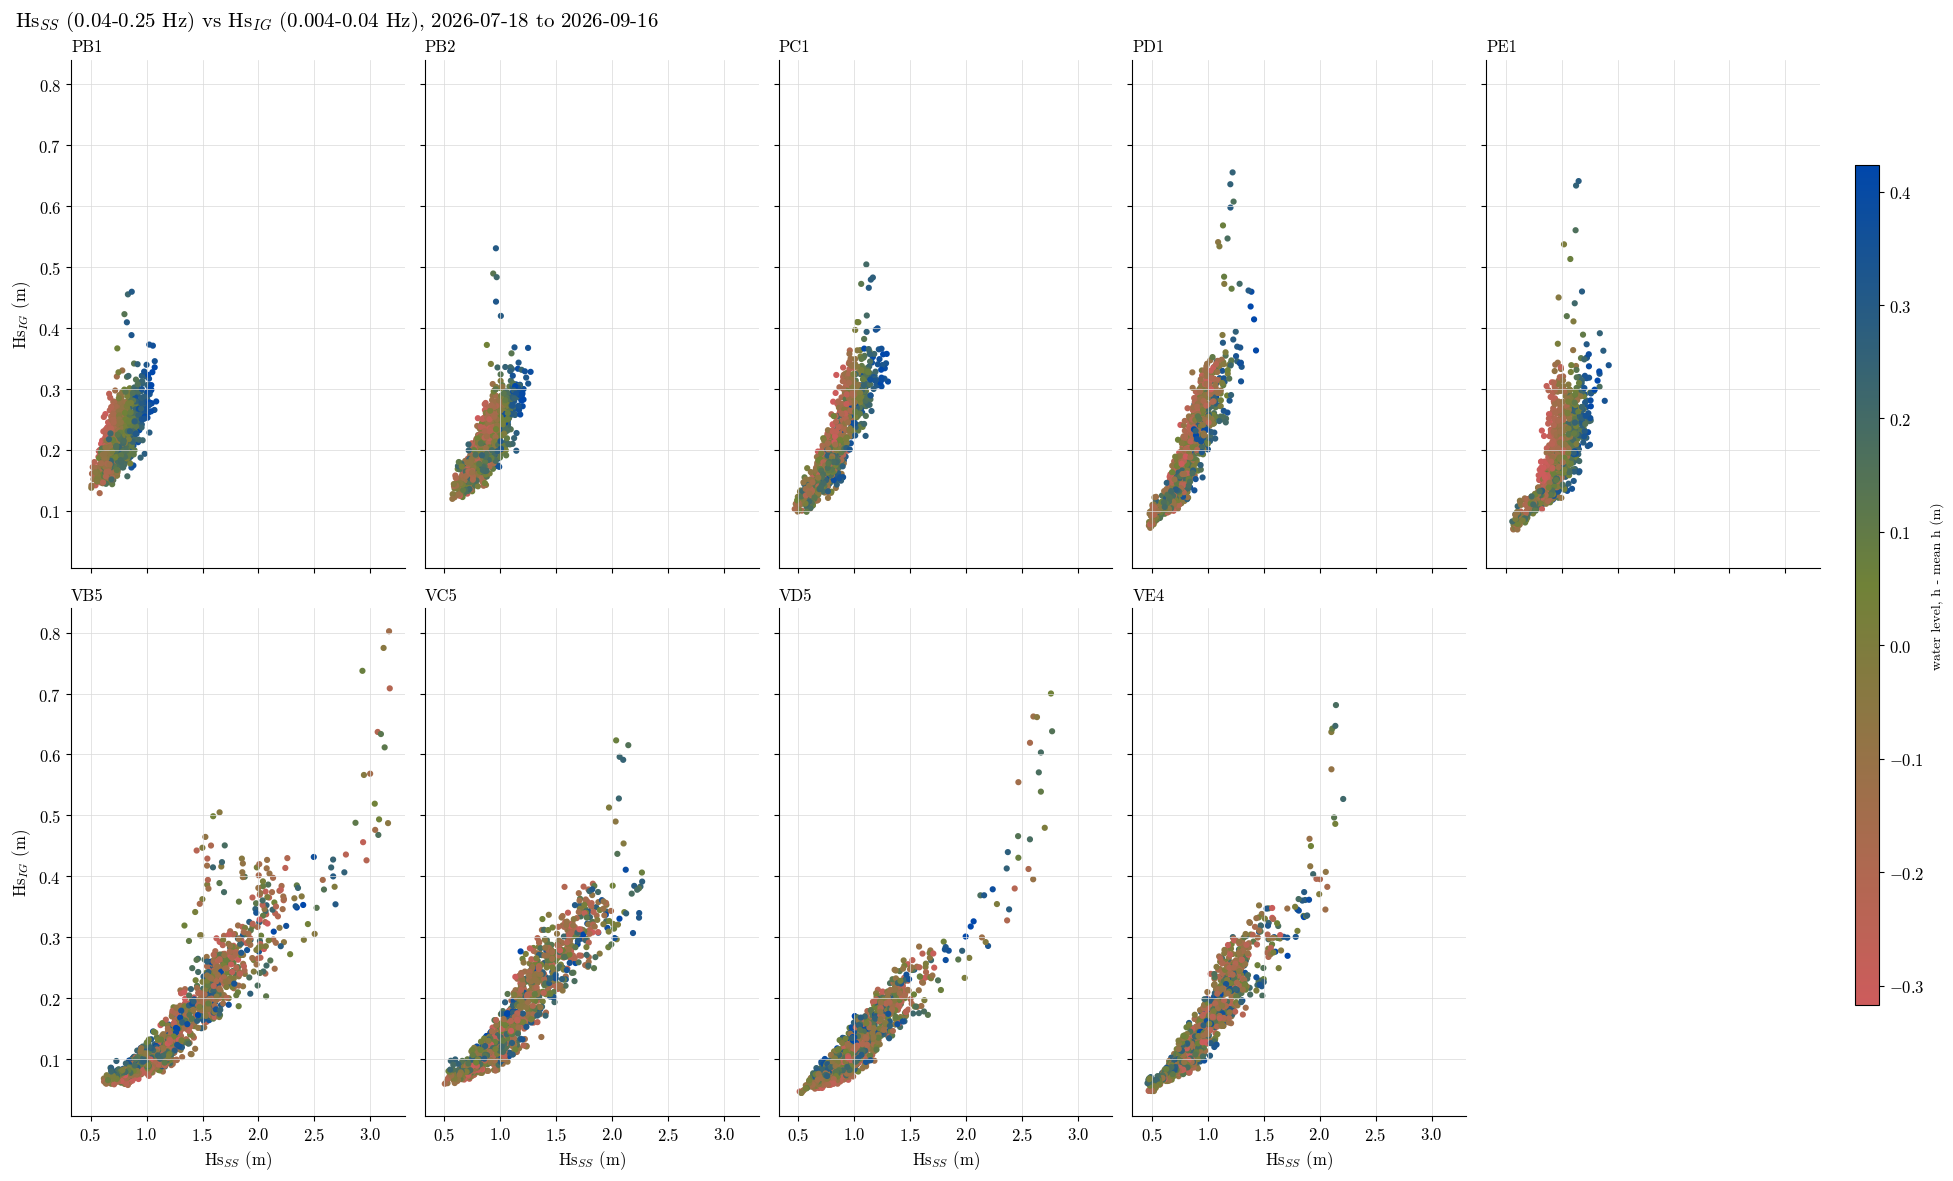

In [34]:
# Hs_SS vs Hs_IG scatter, one panel per sensor, points colored by water level h

# ============ INPUTS ============
SENSORS = ['PB1', 'PB2', 'PC1', 'PD1', 'PE1',   # top row: reef flat P sensors
           'VB5', 'VC5', 'VD5', 'VE4']           # bottom row: 5 m
T_START, T_END = None, None    # e.g. '2026-09-05', '2026-09-12' for one event
IG_BAND = (0.004, 0.04)                         # infragravity [Hz]
SS_BAND = (0.04, 0.25)                          # sea-swell [Hz]
NCOLS   = 5                                     # panels per row
H_TIDE  = True                                  # True: h minus the sensor's mean (tide); False: total depth h
SAVE    = False
# ================================

from matplotlib.colors import LinearSegmentedColormap
h_cmap = LinearSegmentedColormap.from_list('h', ['indianred', '#708238', '#0047AB'])   # low water -> high water
# date window for the title and file name. None -> the data's own first / last time
start = pd.Timestamp(T_START) if T_START is not None else min(pd.Timestamp(spec[S].time.values[0])  for S in SENSORS)
end   = pd.Timestamp(T_END)   if T_END   is not None else max(pd.Timestamp(spec[S].time.values[-1]) for S in SENSORS)

# water level for each sensor (hourly), and one color scale for all panels
h = {}
for S in SENSORS:
    h[S] = spec[S].h_mean.sel(time=slice(T_START, T_END))
    if H_TIDE:
        h[S] = h[S] - spec[S].h_mean.mean()          # minus the sensor's whole-record mean depth
all_h = np.concatenate([h[S].values for S in SENSORS])
h_min, h_max = np.nanpercentile(all_h, 1), np.nanpercentile(all_h, 99)

nrows = int(np.ceil(len(SENSORS) / NCOLS))
fig, axs = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 6 * nrows), sharex=True, sharey=True, squeeze=False)

for ax, S in zip(axs.flat, SENSORS):
    d     = spec[S].sel(time=slice(T_START, T_END))
    hs_ss = Hs_band(d, *SS_BAND)
    hs_ig = Hs_band(d, *IG_BAND)
    sc = ax.scatter(hs_ss, hs_ig, c=h[S], cmap=h_cmap, vmin=h_min, vmax=h_max, s=6, lw=2)
    ax.set_title(S, loc='left', fontweight='bold', fontsize=12)
    ax.grid(True, lw=0.5, color='0.85')

for ax in axs.flat[len(SENSORS):]:          # hide unused panels
    ax.set_visible(False)
for ax in axs[-1, :]:
    ax.set_xlabel(r'Hs$_{SS}$ (m)', fontsize=12)
for ax in axs[:, 0]:
    ax.set_ylabel(r'Hs$_{IG}$ (m)', fontsize=12)

fig.suptitle(f'Hs$_{{SS}}$ ({SS_BAND[0]}-{SS_BAND[1]} Hz) vs Hs$_{{IG}}$ ({IG_BAND[0]}-{IG_BAND[1]} Hz), '
             f'{start:%Y-%m-%d} to {end:%Y-%m-%d}', x=0.01, ha='left', fontsize=15)
fig.tight_layout(rect=(0, 0, 0.92, 1))
cax = fig.add_axes([0.93, 0.15, 0.012, 0.7])                     # colorbar on the right
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('water level, h - mean h (m)' if H_TIDE else 'water depth h (m)')
if SAVE:
    fig.savefig(f'{FIG_DIR}/Hs_SS_vs_IG_{start:%Y-%m-%d}_{end:%Y-%m-%d}.png', dpi=200)
plt.show()


#### A.2 Pressure spectrogram per sensor
Hourly spectra from `spec` (log f × time), one panel per sensor, all on one color scale. *Look for dispersive swell arrivals: frequency rising over days gives the source distance and time. Do arrivals differ across the array (refraction or sheltering)?*
- `Spp` is pressure head and is **not** depth corrected, so the 10 m sensors lose energy faster at high f. `Seta` is depth corrected, but it is capped and set to 0 above `F_CUT`.
- Blank columns are hours dropped by `seg_ok`. The P sensors start 07-28 (PB, PC) or 08-05 (PD, PE).

In [ ]:
# A.2 pressure spectrogram per sensor (log f x time). Look for dispersive swell arrivals: frequency rising over days

# ============ INPUTS ============
SENSORS  = ALL_SENSORS                  # one panel per sensor, top to bottom
T_START, T_END = None, None             # None = whole record, or e.g. '2026-09-05', '2026-09-12'
VARIABLE = 'Spp'                        # 'Spp' = pressure head (not depth corrected), 'Seta' = surface elevation
F_RANGE  = (0.004, 0.3)                 # frequencies shown [Hz]
LOG_F    = True                         # log frequency axis
CLIM_PCT = (30, 99.9)                   # color limits = these percentiles of all plotted values (quiet floor stays pale)
SAVE     = True
# ================================

from matplotlib.colors import LinearSegmentedColormap, LogNorm
spec_cmap = LinearSegmentedColormap.from_list('spec', ['white', '#9DB4DA', '#0047AB', 'indianred', '#5A1A1A'])

# date window. None -> the data's own first / last time
start = pd.Timestamp(T_START) if T_START is not None else min(pd.Timestamp(spec[S].time.values[0])  for S in SENSORS)
end   = pd.Timestamp(T_END)   if T_END   is not None else max(pd.Timestamp(spec[S].time.values[-1]) for S in SENSORS)

# one color scale for every panel, so the sensors can be compared
all_values = np.concatenate([spec[S][VARIABLE].sel(time=slice(start, end), frequency=slice(*F_RANGE)).values.ravel()
                             for S in SENSORS])
norm = LogNorm(vmin=np.nanpercentile(all_values, CLIM_PCT[0]), vmax=np.nanpercentile(all_values, CLIM_PCT[1]))

fig, axs = plt.subplots(len(SENSORS), 1, figsize=(14, 1.5 * len(SENSORS) + 1), sharex=True, sharey=True, squeeze=False)
axs = axs[:, 0]
for ax, S in zip(axs, SENSORS):
    d  = spec[S][VARIABLE].sel(time=slice(start, end), frequency=slice(*F_RANGE))   # dropped hours are NaN -> blank
    d  = d.transpose('frequency', 'time')                                           # rows = frequency, columns = time
    pc = ax.pcolormesh(d.time, d.frequency, d, cmap=spec_cmap, norm=norm, shading='nearest', rasterized=True)
    if LOG_F:
        ax.set_yscale('log')
    ax.set_ylabel(S, color=T_COLOR[S[1]], fontweight='bold', rotation=0, ha='right', va='center')

axs[-1].set_xlim(start, end)
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axs[0].set_title(f'Hourly {VARIABLE} spectra, f = {F_RANGE[0]}-{F_RANGE[1]} Hz (y axis, Hz), UTC', loc='left')
fig.tight_layout(rect=(0, 0, 0.92, 1))
cax = fig.add_axes([0.93, 0.25, 0.012, 0.5])                      # colorbar on the right
fig.colorbar(pc, cax=cax, label=f'{VARIABLE} (m$^2$/Hz)')
if SAVE:
    fig.savefig(f'{FIG_DIR}/A2_spectrogram_{VARIABLE}_{start:%Y-%m-%d}_{end:%Y-%m-%d}.png', dpi=200)
plt.show()


#### B.3b Map of mean currents: event, calm, and event - calm
Mean east/north velocity at each Vector, from hourly means of `u_east`, `v_north` (hours that failed `seg_ok` dropped). Arrows point the way the water flows. *Does the mean flow pattern change during swell events?*
- Event = hours inside `EVENT_WINDOWS` (Fausto, Lala, Lowell by default). Calm = every other hour, or `CALM_WINDOW` if set.
- VB5, VE4 and VE7 had loose prong heads, so their **direction** is suspect (labels in grey italic). The VE4 heading correction from `looseheadloosedata.ipynb` is not applied here.
- The P sensors have no velocity; they are shown as grey dots for reference.

## Transect datasets
One Dataset per transect, with the sensors stacked on a `sensor` dimension. Example: `transects['E'].Seta.sel(sensor='VE10')`.

In [6]:
# build transect datasets. Each transect is labelled A-E. The sensors title tells you which transect by the second letter in the sensor name. 
# combine spectral datasets from each sensor for each transect

transects = {}
for T in 'ABCDE':
    members = [S for S in spec if S[1] == T]           # sensors on this transect (deep -> shallow)
    if not members:
        continue
    transects[T] = xr.concat([spec[S] for S in members], dim=pd.Index(members, name='sensor'),
                             join='outer', combine_attrs='drop')
    print(T, members)

transects['E']

A ['VA10']
B ['VB5']
C ['VC10', 'VC5']
D ['VD10', 'VD5']
E ['VE10', 'VE7', 'VE4']


<xarray.Dataset> Size: 288MB
Dimensions:    (sensor: 3, time: 1420, frequency: 1537)
Coordinates:
  * frequency  (frequency) float64 12kB 0.0 0.001953 0.001953 ... 1.0 1.0 1.0
  * time       (time) datetime64[ns] 11kB 2026-07-18T20:00:00 ... 2026-09-15T...
  * sensor     (sensor) object 24B 'VE10' 'VE7' 'VE4'
Data variables:
    Seta       (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    h_mean     (sensor, time) float64 34kB nan nan nan nan ... 4.215 nan nan
    Spp        (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    Suu        (sensor, time, frequency) float32 26MB nan nan nan ... nan nan
    Svv        (sensor, time, frequency) float32 26MB nan nan nan ... nan nan
    Sww        (sensor, time, frequency) float32 26MB nan nan nan ... nan nan
    Co_pE      (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    Co_pN      (sensor, time, frequency) float64 52MB nan nan nan ... nan nan
    Hs         (sensor, time) float64 34kB nan nan nan nan ... 0.4775 nan nan
    Tp         (sensor, time) float64 34kB nan nan nan nan ... 20.48 nan nan
    Dm         (sensor, time) float64 34kB nan nan nan nan ... 209.4 nan nan

## Whole-record spectrum, all sensors
- One spectrum per sensor over the whole record, or over `T_START`–`T_END`.
- It uses Welch (linear detrend, Hann window) instead of one raw FFT. A single FFT of ~10 M points has only 2 degrees of freedom per bin, so it is pure noise. Welch averages the FFTs of `NPERSEG_FULL`-long windows.
  - Bigger `NPERSEG_FULL` gives finer frequency resolution (lower f) but a noisier spectrum.
- P sensors: pressure only (skipped for velocity). Their 17 s gaps between hourly files are spliced together here, which adds a little leakage; fine for a whole-record view.
- Pressure is shown as pressure head (m²/Hz), **not** depth corrected, so the deep sensors drop off faster at high f.

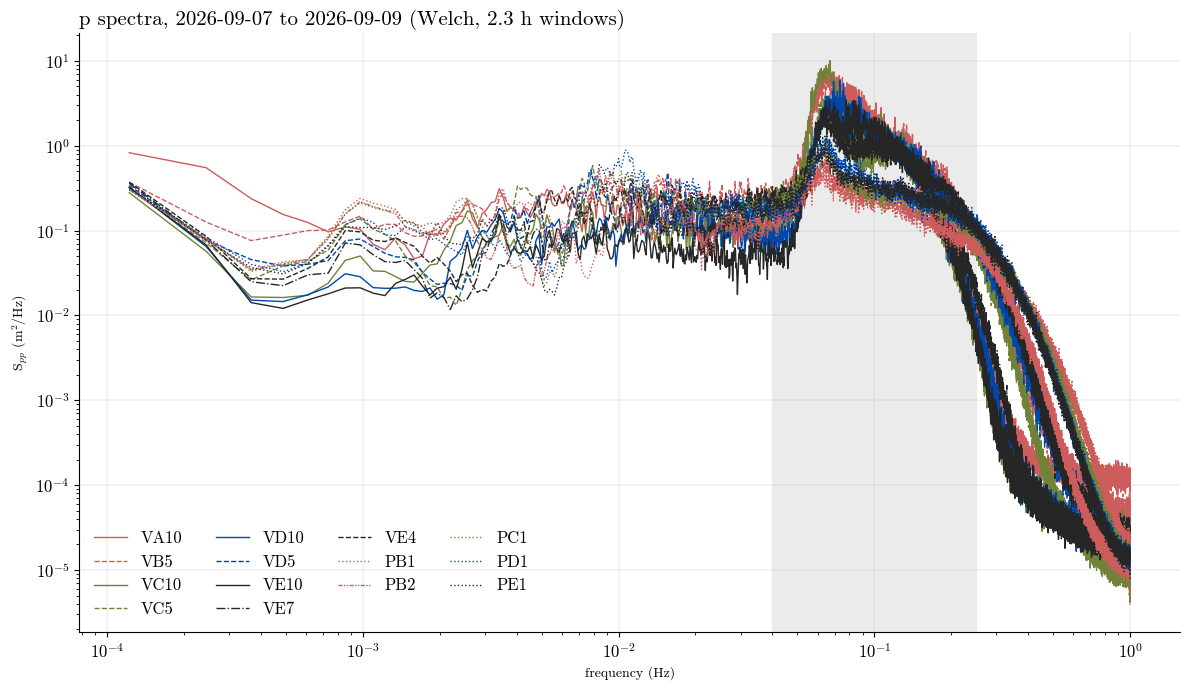

In [38]:
# spectral figure of the whole time series. Like just fft the whole time series and plot the spectra with all of the ADVs on the same plot. Use loglog axis. Use the same color scheme as the other plots. Make sure to label the axes and add a legend.

# ============ INPUTS ============
SENSORS      = ALL_SENSORS
VARIABLE     = 'p'           # 'p' (pressure head), 'u' (cross-shore), 'v' (alongshore), 'w', 'u_east', 'v_north'
T_START, T_END = LOWELL  # None = whole record, or e.g. '2026-09-05', '2026-09-12'
NPERSEG_FULL = 2**14         # 16384 samples = 2.3 h windows, df = 1.2e-4 Hz
SHADE_BAND   = (0.04, 0.25)  # light grey band [Hz], or None
SAVE         = False
# ================================

YLABEL = {'p': 'S$_{pp}$ (m$^2$/Hz)',  'u': 'S$_{uu}$ (m$^2$ s$^{-2}$/Hz)', 'v': 'S$_{vv}$ (m$^2$ s$^{-2}$/Hz)',
          'w': 'S$_{ww}$ (m$^2$ s$^{-2}$/Hz)', 'u_east': 'S (east) (m$^2$ s$^{-2}$/Hz)', 'v_north': 'S (north) (m$^2$ s$^{-2}$/Hz)'}

fig, ax = plt.subplots(figsize=(12, 7))
for S in SENSORS:
    if VARIABLE not in qc[S]:
        print(f'{S} skipped: no {VARIABLE} (P sensors are pressure only)')
        continue
    x = qc[S][VARIABLE].sel(time=slice(T_START, T_END)).values
    if VARIABLE == 'p':
        x = x * 1e4 / (RHO * G)                       # dbar -> m of water
    f, Sxx = welch(x, fs=FS, window='hann', nperseg=NPERSEG_FULL, detrend='linear')
    ax.loglog(f[1:], Sxx[1:], color=T_COLOR[S[1]], ls=DEPTH_LS[S[2:]], lw=1, label=S)   # f[1:] skips f = 0

if SHADE_BAND:
    ax.axvspan(*SHADE_BAND, color='0.92', zorder=0)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel(YLABEL[VARIABLE])
window = 'whole record' if T_START is None else f'{T_START} to {T_END}'
ax.set_title(f'{VARIABLE} spectra, {window} (Welch, {NPERSEG_FULL / FS / 3600:.1f} h windows)', loc='left')
ax.legend(ncol=4, loc='lower left')
ax.grid(True, lw=0.2)
fig.tight_layout()
if SAVE:
    tag = 'all' if T_START is None else f'{T_START}_{T_END}'
    fig.savefig(f'{FIG_DIR}/spectrum_{VARIABLE}_{tag}.png', dpi=200)
plt.show()

## Surface elevation spectra, one transect, one event
- One spectrum per sensor over the whole event (`EVENT`: Fausto, Lala or Lowell, dates from the first cell), computed from the raw 2 Hz pressure. It does **not** use the hourly `spec`.
- Welch: granolas `sensor_spectra` with `NPERSEG_EV`-long windows (50 % overlap), averaged over the event.
  - Each window gets its own depth correction (cosh(kh) with that window's mean depth), so the tide is handled.
  - Longer windows give finer frequency resolution (better IG detail) but fewer windows to average, so a noisier spectrum.
- P sensors are not deployed during Fausto (they start 07-28, PD1 and PE1 on 08-05), so they are skipped then.
- P sensors: the 17 s gaps between their hourly files are filled linearly on a uniform 2 Hz grid, so windows can be longer than one file.
- Above ~0.3 Hz the depth correction amplifies instrument noise at the deep sensors, so `F_RANGE` stops at 0.3 Hz by default.
- The legend gives Hs over `FMIN`–`FMAX` from the event spectrum. That is an energy average over the event, not the peak.


PD1 skipped: no data during Fausto (not deployed yet)


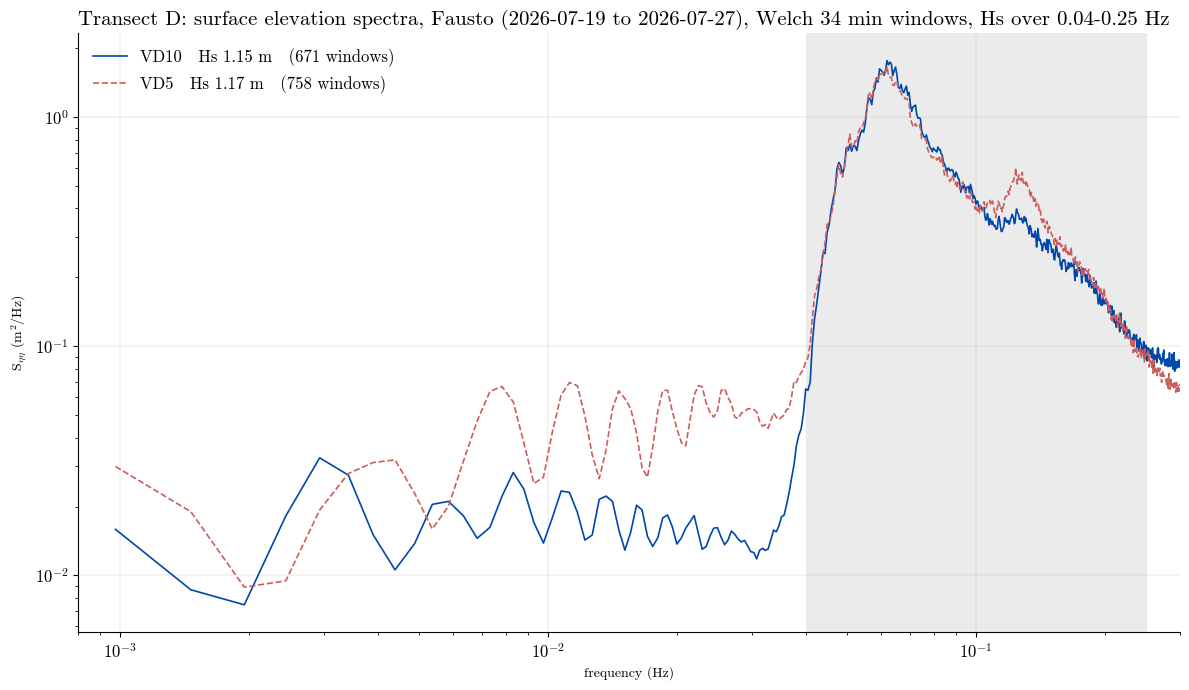

In [32]:
# surface elevation spectra for one transect over one whole event (Welch over the event, from the raw pressure)

# ============ INPUTS ============
TRANSECT   = 'D'              # 'A'-'E'
EVENT      = 'Fausto'         # 'Fausto', 'Lala' or 'Lowell'
NPERSEG_EV = 2**12            # samples per window: 4096 at 2 Hz = 34 min, df = 0.0005 Hz
F_RANGE    = (0.0008, 0.3)     # frequencies shown [Hz]; above ~0.3 Hz the cosh(kh) correction blows up noise at 10 m
F_CUT_EV   = 0.5              # Seta set to 0 above this [Hz]
SHADE_BAND = (0.04, 0.25)     # light grey band [Hz], or None
USE_SEG_OK = True             # drop windows in hours that failed QC (ADVs; P failed files are only outside the events)
SAVE       = False
# ================================

# within one transect, color by depth (same as the transect bulk-stats figure)
DEPTH_COLOR = {'10': '#0047AB', '7': '#708238', '5': 'indianred', '4': 'indianred',
               '1': '0.15', '2': '0.15'}

EVENTS = {'Fausto': FAUSTO, 'Lala': LALA, 'Lowell': LOWELL}   # (start, end) dates set in the first cell
t0, t1 = EVENTS[EVENT]                                    # end date is included in full
sensors = [S for S in ALL_SENSORS if S[1] == TRANSECT]    # deep -> shallow, P sensors last

fig, ax = plt.subplots(figsize=(12, 7))
for S in sensors:
    ds = qc[S].sel(time=slice(t0, t1))
    if ds.time.size < NPERSEG_EV:
        print(f'{S} skipped: no data during {EVENT} (not deployed yet)')
        continue
    df = ds[['p']].to_dataframe()
    if S[0] == 'P':
        df = df.resample('500ms').mean().interpolate(limit=60)   # uniform 2 Hz grid, 17 s gaps between files filled linearly
    df['p_Pa'] = df.p * 1e4                                       # dbar to Pa (what granolas expects)
    df['h']    = (df.p * 1e4 / (RHO * G)).rolling(NPERSEG_EV, center=True, min_periods=1).mean()   # depth, smoothed over a window

    # window spectra, each depth corrected with its own mean depth
    sp = sensor_spectra(df, nperseg=NPERSEG_EV, overlap_frac=0.5,
                        pressure_col='p_Pa', depth_col='h', f_cutoff=F_CUT_EV)
    if USE_SEG_OK and S[0] == 'V':
        win_hour = pd.DatetimeIndex(sp.time.values).floor('h')                # clock hour of each window center
        ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values    # seg_ok for that hour
        sp = sp.where(xr.DataArray(ok.astype(bool), dims='time'))
    n_win = int(sp.Seta.notnull().any('frequency').sum())                    # windows averaged
    seta  = sp.Seta.mean('time')                                              # Welch: average of the window spectra

    df_f = float(seta.frequency[1] - seta.frequency[0])                       # frequency resolution [Hz]
    hs   = 4 * np.sqrt(float(seta.sel(frequency=slice(FMIN, FMAX)).sum()) * df_f)
    seta = seta.sel(frequency=slice(*F_RANGE))
    seta = seta.where(seta > 0)                                               # Seta = 0 above F_CUT_EV: hide it on the log axis
    ax.loglog(seta.frequency, seta, color=DEPTH_COLOR[S[2:]], ls=DEPTH_LS[S[2:]], lw=1.2,
              label=f'{S}   Hs {hs:.2f} m   ({n_win} windows)')
    del df, sp

if SHADE_BAND:
    ax.axvspan(*SHADE_BAND, color='0.92', zorder=0)
ax.set_xlim(F_RANGE)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel(r'S$_{\eta\eta}$ (m$^2$/Hz)')
ax.set_title(f'Transect {TRANSECT}: surface elevation spectra, {EVENT} ({t0} to {t1}), '
             f'Welch {NPERSEG_EV / FS / 60:.0f} min windows, Hs over {FMIN}-{FMAX} Hz', loc='left')
ax.legend(loc='upper left')
ax.grid(True, lw=0.2)
fig.tight_layout()
if SAVE:
    fig.savefig(f'{FIG_DIR}/Seta_transect{TRANSECT}_{EVENT}.png', dpi=200)
plt.show()


#### Transect spectra, IG and SS bands shaded (Mokule'ia style)
Same Welch spectra as the cell above, drawn full-width on log-log axes, with the IG band shaded orange and the SS band blue. One line per sensor, labelled with its median depth.
- **`NPERSEG`**: to resolve down to 0.0007 Hz (period ~24 min) you need the lowest bin at least ~3 bins above 0. `2**14` (8192 s = 2.3 h, df = 1.2e-4 Hz) puts 0.0007 Hz at bin ~6. `2**13` (68 min, df = 2.4e-4 Hz) gives bin ~3, the minimum, but twice the windows (less noise). Longer windows than `2**14` leave few windows in a 2-day event (`2**15`: ~20 windows, ~40 dof).
- Degrees of freedom ~ 2 x (number of windows, 50 % overlap, Hann). Whole record: use `2**14` or larger. Two-day event: `2**13` to `2**14`.
- Below ~0.002 Hz the pressure is not only surface waves (tide and slow drift residuals), so read the lowest decade with care.


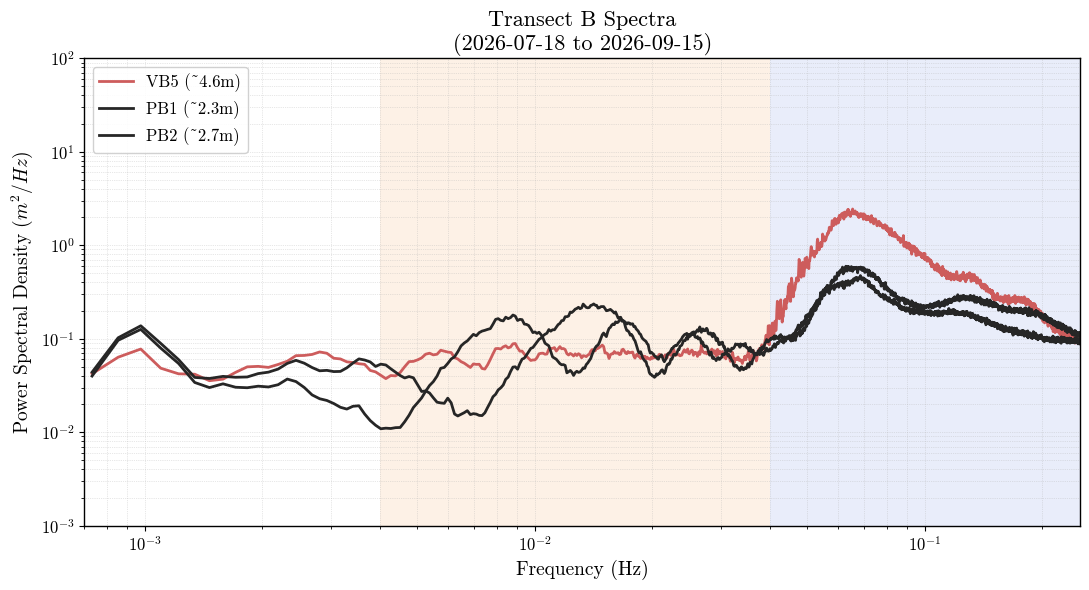

In [20]:
# surface elevation spectra for one transect over one event / date range, IG (orange) and SS (blue) bands shaded

# ============ INPUTS ============
TRANSECT   = 'B'              # 'A'-'E'
PERIOD     = FULL           # (start, end) dates: FAUSTO, LALA, LOWELL, FULL or e.g. ('2026-09-05', '2026-09-12')
NPERSEG    = 2**14            # samples per window at 2 Hz: 2**14 = 2.3 h, df = 1.2e-4 Hz (0.0007 Hz = bin ~6). 2**13 = 68 min, df = 2.4e-4 Hz
F_RANGE    = (0.0007, 0.25)   # frequencies shown [Hz]
IG_BAND    = (0.004, 0.04)    # orange shading [Hz]
SS_BAND    = (0.04, 0.25)     # blue shading [Hz]
F_CUT_EV   = 0.5              # Seta set to 0 above this [Hz]
YLIM       = (1e-3, 1e2)      # m^2/Hz, or None for auto
USE_SEG_OK = True             # drop windows in hours that failed QC (ADVs only)
SAVE       = False
# ================================

DEPTH_COLOR = {'10': '#0047AB', '7': '#708238', '5': 'indianred', '4': 'indianred',
               '1': '0.15', '2': '0.15'}

t0, t1 = PERIOD
sensors = [S for S in ALL_SENSORS if S[1] == TRANSECT]

with plt.rc_context({'axes.spines.top': True, 'axes.spines.right': True, 'axes.linewidth': 1.0}):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.axvspan(*IG_BAND, color='#f5a35a', alpha=0.15, lw=0, zorder=0)
    ax.axvspan(*SS_BAND, color='#4a6fd8', alpha=0.12, lw=0, zorder=0)
    for S in sensors:
        ds = qc[S].sel(time=slice(t0, t1))
        if ds.time.size < NPERSEG:
            print(f'{S} skipped: fewer than NPERSEG samples in {t0} to {t1}')
            continue
        df = ds[['p']].to_dataframe()
        if S[0] == 'P':
            df = df.resample('500ms').mean().interpolate(limit=60)       # uniform 2 Hz grid, hourly-file gaps filled
        df['p_Pa'] = df.p * 1e4
        df['h']    = (df.p * 1e4 / (RHO * G)).rolling(NPERSEG, center=True, min_periods=1).mean()
        sp = sensor_spectra(df, nperseg=NPERSEG, overlap_frac=0.5,
                            pressure_col='p_Pa', depth_col='h', f_cutoff=F_CUT_EV)
        if USE_SEG_OK and S[0] == 'V':
            win_hour = pd.DatetimeIndex(sp.time.values).floor('h')
            ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values
            sp = sp.where(xr.DataArray(ok.astype(bool), dims='time'))
        n_win = int(sp.Seta.notnull().any('frequency').sum())
        seta  = sp.Seta.mean('time').sel(frequency=slice(*F_RANGE))
        seta  = seta.where(seta > 0)
        depth = float(ds.depth_h.median())
        ax.loglog(seta.frequency, seta, color=DEPTH_COLOR[S[2:]], lw=2, label=f'{S} (~{depth:.1f}m)')
        del df, sp

    ax.set_xlim(F_RANGE)
    if YLIM: ax.set_ylim(YLIM)
    ax.set_xlabel('Frequency (Hz)', fontsize=14)
    ax.set_ylabel(r'Power Spectral Density ($m^2/Hz$)', fontsize=14)
    ax.set_title(f'Transect {TRANSECT} Spectra\n({t0} to {t1})', fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
    ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.6)
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/Seta_bands_transect{TRANSECT}_{t0}_{t1}.png', dpi=200)
    plt.show()


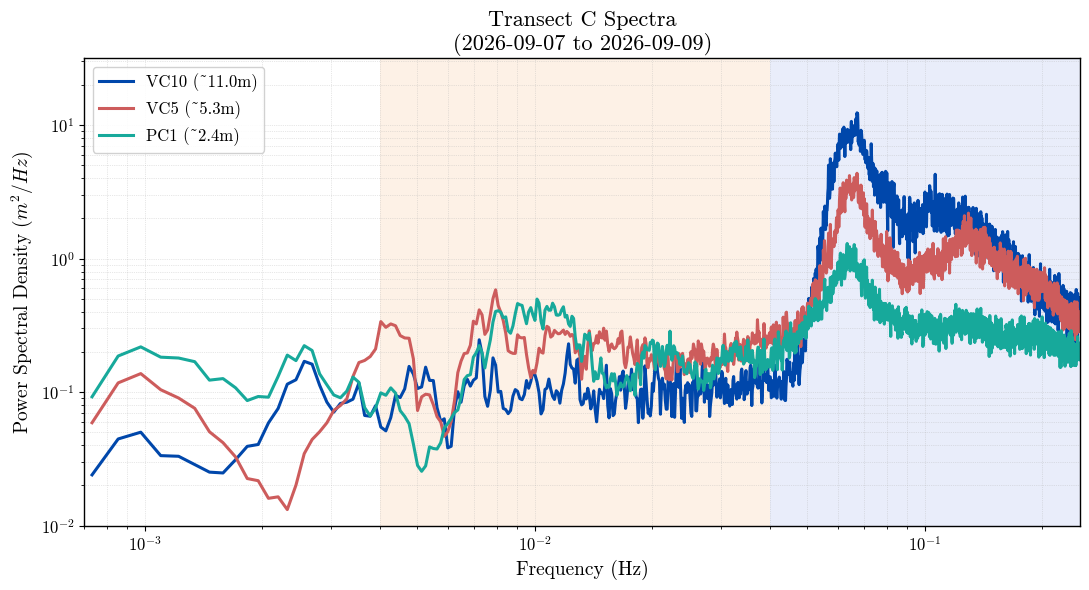

In [27]:
# surface elevation spectra per transect over one event / date range, IG (orange) and SS (blue) bands shaded

# ============ INPUTS ============
TRANSECT   = 'C'              # 'A'-'E' for one transect, or 'ALL' for one panel per transect
PERIOD     = LOWELL           # (start, end) dates: FAUSTO, LALA, LOWELL, FULL or e.g. ('2026-09-05', '2026-09-12')
NPERSEG    = 2**14            # samples per window at 2 Hz: 2**14 = 2.3 h, df = 1.2e-4 Hz (0.0007 Hz = bin ~6). 2**13 = 68 min, df = 2.4e-4 Hz
F_RANGE    = (0.0007, 0.25)   # frequencies shown [Hz]
IG_BAND    = (0.004, 0.04)    # orange shading [Hz]
SS_BAND    = (0.04, 0.25)     # blue shading [Hz]
F_CUT_EV   = 0.5              # Seta set to 0 above this [Hz]
YLIM       = None             # (lo, hi) in m^2/Hz, or None = fit to the data (about half a decade of padding)
SHARE_Y    = False            # 'ALL' only: True = same y-axis in every panel (compare transects), False = each panel fit to its own lines
LW         = 2.2
USE_SEG_OK = True             # drop windows in hours that failed QC (ADVs only)
SAVE       = False
# ================================

# ADVs by depth (same as the bulk-stats figures); P sensors each get their own playful colour
SENSOR_COLOR = {'10': '#0047AB', '7': '#708238', '5': 'indianred', '4': 'indianred'}
P_COLOR      = {'PB1': '#8e5bd9', 'PB2': '#e0529c', 'PC1': '#17a99b', 'PD1': '#17a99b', 'PE1': '#17a99b'}
def line_color(S):
    return P_COLOR[S] if S[0] == 'P' else SENSOR_COLOR[S[2:]]

t0, t1 = PERIOD
transects = list('ABCDE') if TRANSECT == 'ALL' else [TRANSECT]

def event_spectrum(S):
    """Welch-averaged surface elevation spectrum of sensor S over PERIOD, or None if there are too few samples."""
    ds = qc[S].sel(time=slice(t0, t1))
    if ds.time.size < NPERSEG:
        print(f'{S} skipped: fewer than NPERSEG samples in {t0} to {t1}')
        return None
    df = ds[['p']].to_dataframe()
    if S[0] == 'P':
        df = df.resample('500ms').mean().interpolate(limit=60)       # uniform 2 Hz grid, hourly-file gaps filled
    df['p_Pa'] = df.p * 1e4
    df['h']    = (df.p * 1e4 / (RHO * G)).rolling(NPERSEG, center=True, min_periods=1).mean()
    sp = sensor_spectra(df, nperseg=NPERSEG, overlap_frac=0.5, pressure_col='p_Pa', depth_col='h', f_cutoff=F_CUT_EV)
    if USE_SEG_OK and S[0] == 'V':
        win_hour = pd.DatetimeIndex(sp.time.values).floor('h')
        ok = ds.seg_ok.to_series().reindex(win_hour).fillna(False).values
        sp = sp.where(xr.DataArray(ok.astype(bool), dims='time'))
    seta = sp.Seta.mean('time').sel(frequency=slice(*F_RANGE))
    return seta.where(seta > 0), float(ds.depth_h.median())

# compute everything first so the y-axis can be fit to the data
results = {T: {S: event_spectrum(S) for S in ALL_SENSORS if S[1] == T} for T in transects}

def ylim_for(Ts):
    vals = np.concatenate([r[0].values[np.isfinite(r[0].values)]
                           for T in Ts for r in results[T].values() if r is not None])
    return 10**(np.floor(np.log10(vals.min()) * 2) / 2), 10**(np.ceil(np.log10(vals.max()) * 2) / 2)   # round out to half decades

ncol = 1 if len(transects) == 1 else 3
nrow = int(np.ceil(len(transects) / ncol))
with plt.rc_context({'axes.spines.top': True, 'axes.spines.right': True, 'axes.linewidth': 1.0}):
    fig, axs = plt.subplots(nrow, ncol, figsize=(11, 6) if ncol == 1 else (18, 5.5 * nrow),
                            squeeze=False, sharex=False, sharey=SHARE_Y and len(transects) > 1)
    for ax in axs.flat[len(transects):]:
        ax.set_visible(False)
    for ax, T in zip(axs.flat, transects):
        ax.axvspan(*IG_BAND, color='#f5a35a', alpha=0.15, lw=0, zorder=0)
        ax.axvspan(*SS_BAND, color='#4a6fd8', alpha=0.12, lw=0, zorder=0)
        for S, r in results[T].items():
            if r is None:
                continue
            seta, depth = r
            ax.loglog(seta.frequency, seta, color=line_color(S), lw=LW, label=f'{S} (~{depth:.1f}m)')
        ax.set_xlim(F_RANGE)
        if YLIM:
            ax.set_ylim(YLIM)
        elif not (SHARE_Y and len(transects) > 1):
            ax.set_ylim(ylim_for([T]))
        ax.set_title(f'Transect {T}' if len(transects) > 1 else f'Transect {T} Spectra\n({t0} to {t1})',
                     fontsize=16, fontweight='bold')
        ax.set_xlabel('Frequency (Hz)', fontsize=14)
        ax.set_ylabel(r'Power Spectral Density ($m^2/Hz$)', fontsize=14)
        ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
        ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.6)
    if len(transects) > 1:
        if SHARE_Y and not YLIM:
            axs.flat[0].set_ylim(ylim_for(transects))
        fig.suptitle(f'Surface elevation spectra ({t0} to {t1})', fontsize=18, fontweight='bold')
    fig.tight_layout()
    if SAVE:
        fig.savefig(f'{FIG_DIR}/Seta_bands_transect{TRANSECT}_{t0}_{t1}.png', dpi=200)
    plt.show()
